# COMP3710 — Pattern Recognition
## Lab 2 · Experimental Study

# COMP3710 — 模式识别
## 实验二 · 实验研究

**Fourier Analysis · Face Recognition · Residual Learning · Brain MRI Modelling**

**傅里叶分析 · 人脸识别 · 残差学习 · 脑部 MRI 建模**

This study compares numerical transforms, classical feature extraction and neural networks, followed by generative modelling and semantic segmentation of brain MRI slices. Experimental outputs are produced by the code and stored with their execution environment.

本实验比较数值变换、传统特征提取和神经网络，并进一步研究脑部 MRI 图像的生成与分割。图表和数值由代码实际运行产生，同时记录运行环境。

| Study / 实验 | Method / 方法 | Evaluation / 评价指标 |
|---|---|---|
| Signal reconstruction / 信号重建 | Fourier series; explicit DFT; FFT / 傅里叶级数、显式 DFT 与 FFT | Reconstruction, numerical agreement, runtime scaling / 重建、数值一致性、耗时变化 |
| Face recognition / 人脸识别 | Eigenfaces + Random Forest; two-layer CNN / 特征脸＋随机森林、两层 CNN | Explained variance, classification metrics / 方差解释率、分类指标 |
| Object recognition / 物体识别 | ResNet-18 on CIFAR-10 / 使用 ResNet-18 | Test accuracy, training time / 测试准确率、训练时间 |
| MRI representation / MRI 特征表示 | Variational autoencoder / 变分自编码器 | Reconstruction and latent-space visualisation / 重建及潜在空间可视化 |
| MRI segmentation / MRI 分割 | UNet | Per-class Dice similarity coefficient / 逐类 Dice 系数 |
| MRI synthesis / MRI 图像生成 | DCGAN | Generated samples, diversity and training dynamics / 生成样本、多样性与训练变化 |


### Execution Record · 运行记录说明

Saved outputs below document the completed training and evaluations. Configuration defaults now use demonstration mode; experiment switches are off. Saved output timestamps and hyperparameters describe the original runs. New outputs are produced only when the corresponding code is executed.

下方保留已完成训练与评估的真实输出。当前默认配置为演示模式，各实验开关默认关闭。历史输出中的时间和训练参数属于当时的运行记录；重新执行相应代码后才会产生新的输出。


## Experimental Environment

## 实验环境

Portable source archive, dependency versions and compute device.

包含可恢复的项目源码、依赖库版本和使用的计算设备。


In [1]:
#@title Source Initialisation
import base64, hashlib, io, os, sys, zipfile
from pathlib import Path
PROJECT = Path("/content/COMP3710_Lab2")
PROJECT.mkdir(parents=True, exist_ok=True)
SOURCE_ZIP_BASE64 = '...'
archive = base64.b64decode(SOURCE_ZIP_BASE64)
assert hashlib.sha256(archive).hexdigest() == '293f3096ba80b4882483c047de987c47b15657f185e68383f84eea9b7b79a1f4', "Source integrity check failed"
with zipfile.ZipFile(io.BytesIO(archive)) as z:
    for entry in z.infolist():
        destination = (PROJECT / entry.filename).resolve()
        assert destination.is_relative_to(PROJECT.resolve())
        destination.parent.mkdir(parents=True, exist_ok=True)
        # 保留已有源码，确保实验修改可复现。
        if not destination.exists():
            destination.write_bytes(z.read(entry))
os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
print("Source files ready:", PROJECT)



Source files ready: /content/COMP3710_Lab2


In [2]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
subprocess.run([sys.executable, "tools/check_environment.py"], check=True)
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected device:", DEVICE)
if DEVICE == "cpu":
    print("CUDA available: False")


Selected device: cuda


In [ ]:
#@title Maintenance Record · 环境与备份记录
RUN_MAINTENANCE = False #@param {type:"boolean"}
if RUN_MAINTENANCE:
    from google.colab import drive
    from pathlib import Path

    drive.mount("/content/drive")

    backup = Path("/content/drive/MyDrive/COMP3710_Lab2")

    for name, relative in [
        ("ResNet 模型", "runs/cifar/resnet18_best.pt"),
        ("VAE 模型", "runs/vae/vae_best.pt"),
        ("UNet 模型", "runs/unet/unet_best.pt"),
        ("UNet 测试结果", "runs/unet/live_demo.json"),
        ("CIFAR 数据", "data/cifar10"),
    ]:
        print(f"{name}：{(backup / relative).exists()}")


Mounted at /content/drive
ResNet 模型：True
VAE 模型：True
UNet 模型：True
UNet 测试结果：True
CIFAR 数据：True


### Experiment Configuration

### 实验配置

Execution mode, enabled experiments and training hyperparameters.

设置训练或演示模式、启用的实验，以及训练轮数、批大小等超参数。


In [20]:
#@title Experiment Configuration
MODE = "demo" #@param ["train", "demo"]
RUN_FACES = True #@param {type:"boolean"}
RUN_CIFAR = False #@param {type:"boolean"}
RUN_VAE = False #@param {type:"boolean"}
RUN_UNET = False #@param {type:"boolean"}
RUN_GAN = False #@param {type:"boolean"}
RESUME_INTERRUPTED_RUN = False #@param {type:"boolean"}
SAVE_TO_DRIVE = True #@param {type:"boolean"}
CIFAR_EPOCHS = 100 #@param {type:"integer"}
CIFAR_BATCH = 512 #@param {type:"integer"}
UNET_EPOCHS = 80 #@param {type:"integer"}
UNET_BATCH = 8 #@param {type:"integer"}
print("Mode:", MODE, "| enabled:", dict(faces=RUN_FACES, cifar=RUN_CIFAR, vae=RUN_VAE, unet=RUN_UNET, gan=RUN_GAN))


Mode: demo | enabled: {'faces': True, 'cifar': False, 'vae': False, 'unet': False, 'gan': False}


### Artifact Storage

### 结果保存

Model checkpoints, figures and numerical results are stored under `runs/`.

模型检查点（保存的模型状态）、图表和数值结果统一放在 `runs/` 中。


In [4]:
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    target = Path("/content/drive/MyDrive/COMP3710_Lab2/runs")
    target.mkdir(parents=True, exist_ok=True)
    local = PROJECT / "runs"
    if local.is_symlink():
        assert local.resolve() == target.resolve(), "runs already points to a different destination"
    else:
        if local.exists() and any(local.iterdir()):
            raise RuntimeError("runs already contains results. Download/back them up before changing storage.")
        if local.exists():
            local.rmdir()  # Only removes an empty directory.
        local.symlink_to(target, target_is_directory=True)
    print("Training results will be saved to:", target)
else:
    print("Artifact storage: session disk")


Mounted at /content/drive
Training results will be saved to: /content/drive/MyDrive/COMP3710_Lab2/runs


In [5]:
from IPython.display import display, Image as NotebookImage, HTML
import json
def run(*arguments):
    command = [sys.executable, *map(str, arguments)]
    print("Running:", " ".join(command))
    with subprocess.Popen(command, cwd=PROJECT, stdout=subprocess.PIPE,
                          stderr=subprocess.STDOUT, text=True, bufsize=1) as process:
        for line in process.stdout:
            print(line, end="", flush=True)
        code = process.wait()
    if code:
        raise RuntimeError(f"Command exited with code {code}; inspect the error above.")
def show(folder, names):
    for name in names:
        path = PROJECT / "runs" / folder / name
        if path.exists():
            print(name)
            if path.suffix == ".png":
                display(NotebookImage(filename=str(path), width=900))
            elif path.suffix == ".json":
                print(json.dumps(json.loads(path.read_text()), indent=2, ensure_ascii=False))
RESUME_ARGS = ["--resume"] if RESUME_INTERRUPTED_RUN and MODE == "train" else []


## Datasets and Evaluation Protocol

## 数据集与评估方法


- **LFW:** identity classification; stratified training, validation and test partitions. PCA is fitted using training data only.

**LFW 人脸数据：**按人物身份分类，划分训练集、验证集和测试集时尽量保持各类别比例。PCA 只从训练集学习特征。

- **CIFAR-10:** 45,000 training, 5,000 validation and 10,000 test examples; model selection uses validation data.

**CIFAR-10：**45,000 张训练、5,000 张验证、10,000 张测试图像；用验证集选模型，测试集用于最终评估。

- **Brain MRI:** 9,664 training, 1,120 validation and 544 test slices. The supplied partitions have disjoint subject IDs. Labels are mapped from grayscale values 0/85/170/255 to four categorical classes.

**脑部 MRI：**训练、验证、测试分别有 9,664、1,120、544 张切片。三组没有重复的受试者，避免同一个人的不同切片同时进入训练和测试。标签灰度值 0/85/170/255 对应四个类别。


The MRI audit checks image–mask pairing, dimensions, label values and subject separation.

数据检查核对图片与标签是否一一对应、尺寸是否正确、类别值是否合法，以及不同集合之间是否有重复受试者。



In [18]:
#@title Cached Dataset Recovery · 数据缓存恢复
from pathlib import Path
import shutil

cache_backup = Path("/content/drive/MyDrive/COMP3710_Lab2/data")
if RUN_CIFAR:
    destination = PROJECT / "data/cifar10"
    if not (destination / "cifar-10-batches-py").is_dir():
        source = cache_backup / "cifar10"
        if source.is_dir():
            shutil.copytree(source, destination, dirs_exist_ok=True)
    if MODE == "demo":
        assert (destination / "cifar-10-batches-py").is_dir(), "CIFAR-10 cache unavailable."

if RUN_VAE or RUN_UNET or RUN_GAN:
    from lab.data import resolve_mri, extract_mri_archive
    MRI_ROOT = str(PROJECT / "data")
    try:
        resolve_mri(MRI_ROOT)
    except FileNotFoundError:
        archive = cache_backup / "keras_png_slices_data.zip"
        if archive.is_file():
            local_archive = PROJECT / "keras_png_slices_data.zip"
            if not local_archive.exists():
                shutil.copy2(archive, local_archive)
            extract_mri_archive(local_archive, MRI_ROOT)
print("Dataset cache check complete.")


Dataset cache check complete.


In [8]:
MRI_ROOT = "" #@param {type:"string"}
if RUN_VAE or RUN_UNET or RUN_GAN:
    from lab.data import resolve_mri, extract_mri_archive
    if not MRI_ROOT:
        MRI_ROOT = str(PROJECT / "data")
    try:
        resolve_mri(MRI_ROOT)
    except FileNotFoundError:
        from google.colab import files
        print("MRI archive input")
        uploaded = files.upload()
        candidates = [Path(name) for name in uploaded if name.lower().endswith(".zip")]
        if len(candidates) != 1:
            raise ValueError("Expected exactly one MRI ZIP archive.")
        extract_mri_archive(candidates[0], MRI_ROOT)
        del uploaded
    run("-m", "lab.data", "--root", MRI_ROOT)
else:
    print("No MRI task enabled; data upload skipped.")


Running: /usr/bin/python3 -m lab.data --root /content/COMP3710_Lab2/data
train 9664 images; 302 subjects
validate 1120 images; 35 subjects
test 544 images; 17 subjects
Subject split audit passed. Root: /content/COMP3710_Lab2/data/keras_png_slices_data


In [ ]:
#@title Maintenance Record · 环境与备份记录
RUN_MAINTENANCE = False #@param {type:"boolean"}
if RUN_MAINTENANCE:
    from pathlib import Path
    import shutil

    archives = list(Path.cwd().glob("keras_png_slices_data*.zip"))
    assert archives, "当前目录未找到 MRI 压缩包"
    archive = max(archives, key=lambda p: p.stat().st_mtime)

    destination = Path(
        "/content/drive/MyDrive/COMP3710_Lab2/data/keras_png_slices_data.zip"
    )
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(archive, destination)
    print("MRI 压缩包已备份，以后可从 Drive 恢复。")


MRI 压缩包已备份，以后可从 Drive 恢复。


## Part 1 — Fourier Reconstruction and Transform Performance

## Part 1 — 傅里叶重建与变换性能

A square wave is approximated by summing odd harmonics:

方波可以由多个奇数倍频率的正弦波相加近似得到。

$$s_K(t)=\frac{4}{\pi}\sum_{k=0}^{K-1}\frac{\sin(2\pi(2k+1)f_0t)}{2k+1}.$$

公式中，K 是参与相加的项数，f₀ 是基频，t 是时间；第 k 项的频率为 (2k+1)f₀，振幅随奇数序号增大而减小。

The comparison uses 1, 3, 5, 20 and 50 terms. Gibbs oscillations occur near discontinuities. The explicit DFT has $O(N^2)$ complexity, while FFT has $O(N\log N)$ complexity.

比较 1、3、5、20、50 项的重建结果。项数越多，整体越接近方波，但跳变附近仍有 Gibbs（吉布斯）振荡。直接计算 DFT 的复杂度是 O(N²)，FFT 则是 O(N log N)。

Timing uses $N=256,512,1024,2048$, warm-up runs and the median of three repetitions. CUDA timing is synchronised; input transfers are excluded. Numerical agreement is checked against NumPy FFT.

计时比较 256、512、1024、2048 个采样点；先预热，再取三次耗时的中位数。GPU 计时等待计算真正完成，不包含输入从 CPU 传到 GPU 的时间。以 NumPy FFT 为参考核对数值结果。


### Core Implementation · 关键代码实现

**`lab/part1.py` · `square_wave_fourier`**

```python
def square_wave_fourier(t, f0=1.0, count=50):
    # DEMO P1-A: 将 1、3、5…倍基频的正弦波相加来逼近方波。
    # 50 项对应 1 到 99 倍基频，频率越高的项权重越小。
    n = torch.arange(1, 2 * count, 2, device=t.device, dtype=t.dtype)[:, None]
    return (4 / torch.pi) * (torch.sin(2 * torch.pi * n * f0 * t[None, :]) / n).sum(0)
```

**`lab/part1.py` · `naive_dft_torch`**

```python
def naive_dft_torch(x, block=256):
    """Explicit DFT, O(N^2); block rows limit memory. No built-in FFT."""
    # DEMO P1-B: 一次生成一批频率的 DFT 系数，再用矩阵乘法计算各频率的分量。
    # 分块可减少内存占用；GPU 同时处理更多运算，但复杂度仍是 O(N²)。
    size = x.numel()
    n = torch.arange(size, dtype=x.dtype, device=x.device)[None, :]
    out = torch.empty(size, dtype=torch.complex128, device=x.device)
    for start in range(0, size, block):
        k = torch.arange(start, min(start + block, size), dtype=x.dtype, device=x.device)[:, None]
        matrix = torch.exp((-2j * torch.pi / size) * (k * n))
        out[start:start + len(k)] = matrix @ x.to(torch.complex128)
    return out
```


Running: /usr/bin/python3 -m lab.part1 --device cuda
N= 256 | NumPy naive DFT              | 0.117737 s | agrees=True
N= 256 | NumPy FFT                    | 0.000040 s | agrees=True
N= 256 | PyTorch explicit DFT CPU     | 0.002687 s | agrees=True
N= 256 | PyTorch explicit DFT GPU     | 0.000396 s | agrees=True
Fastest -> slowest: NumPy FFT -> PyTorch explicit DFT GPU -> PyTorch explicit DFT CPU -> NumPy naive DFT
N= 512 | NumPy naive DFT              | 0.938349 s | agrees=True
N= 512 | NumPy FFT                    | 0.000035 s | agrees=True
N= 512 | PyTorch explicit DFT CPU     | 0.010504 s | agrees=True
N= 512 | PyTorch explicit DFT GPU     | 0.001194 s | agrees=True
Fastest -> slowest: NumPy FFT -> PyTorch explicit DFT GPU -> PyTorch explicit DFT CPU -> NumPy naive DFT
N=1024 | NumPy naive DFT              | 2.036844 s | agrees=True
N=1024 | NumPy FFT                    | 0.000054 s | agrees=True
N=1024 | PyTorch explicit DFT CPU     | 0.050102 s | agrees=True
N=1024 | PyTorch expli

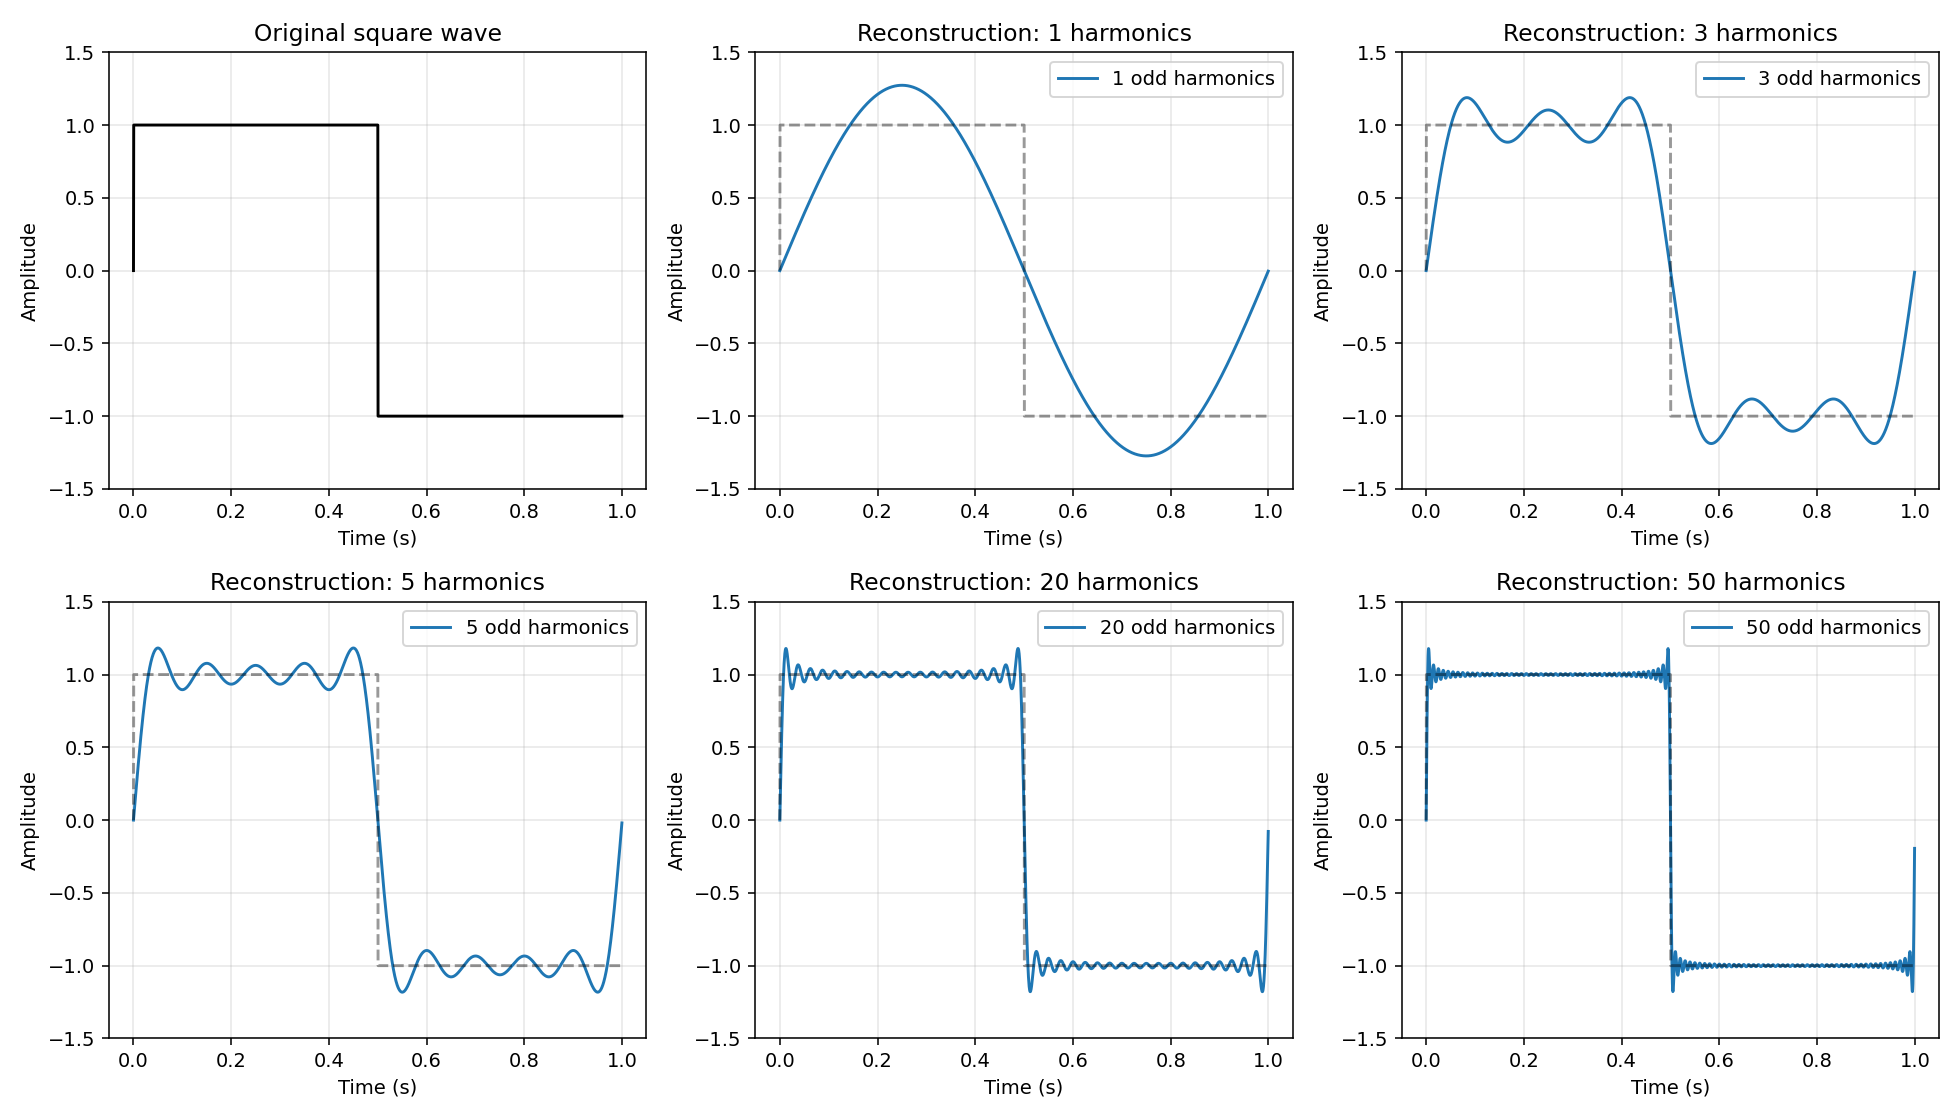

spectrum.png


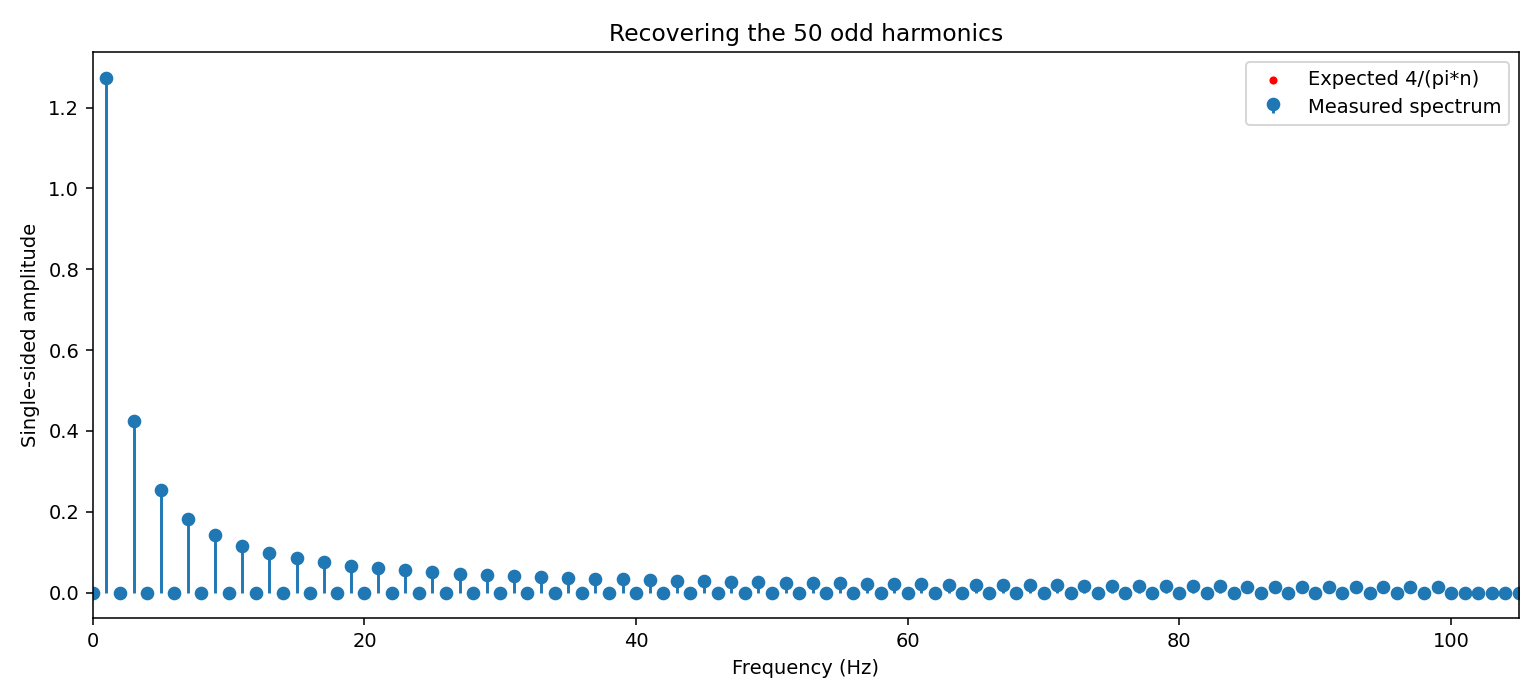

timings.png


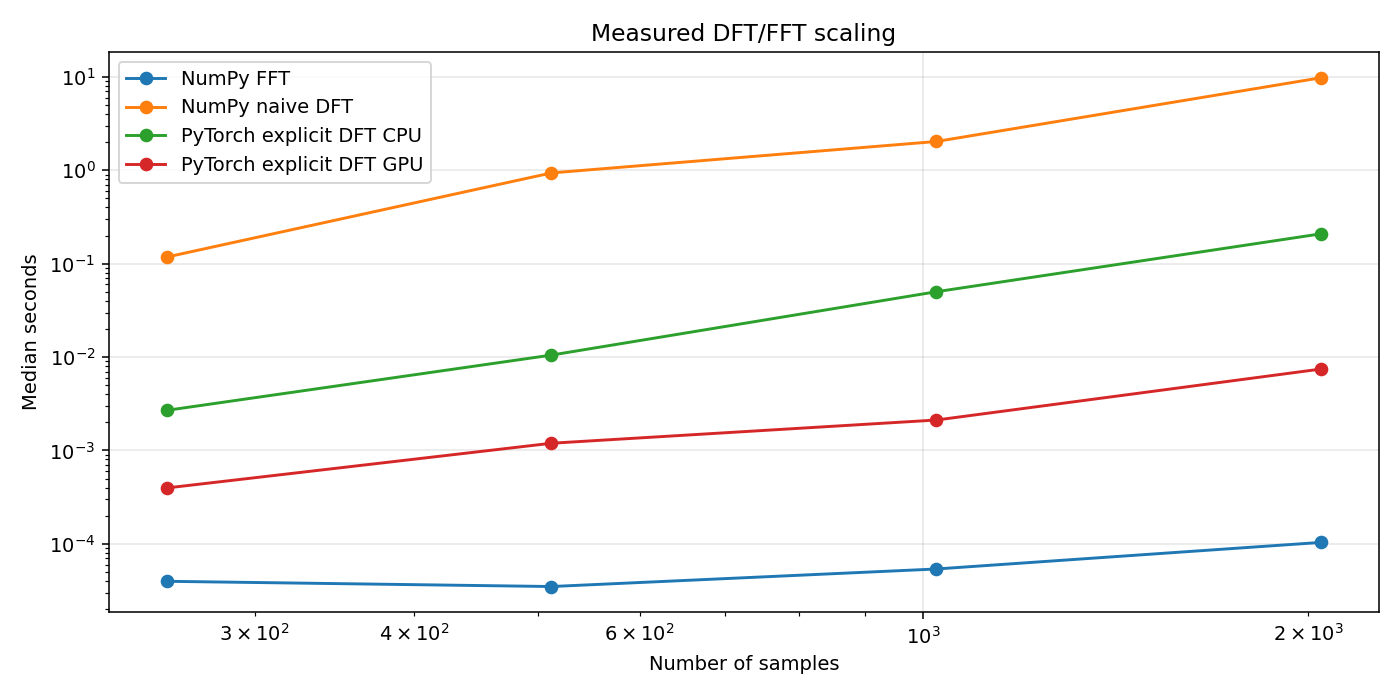

metrics.json
{
  "environment": {
    "python": "3.13.15",
    "torch": "2.11.0+cu128",
    "numpy": "2.1.3",
    "host": "0421d0d7e253",
    "device": "cuda",
    "gpu": "Tesla T4",
    "cuda_runtime": "12.8",
    "slurm_job_id": null,
    "utc": "2026-09-13T17:31:27Z"
  },
  "gpu_measured": true,
  "records": [
    {
      "N": 256,
      "method": "NumPy naive DFT",
      "median_seconds": 0.11773699600007603,
      "samples_seconds": [
        0.1501346290001493,
        0.11687045200005741,
        0.11773699600007603
      ],
      "max_abs_error": 3.8621891205113315e-12,
      "agrees": true
    },
    {
      "N": 256,
      "method": "NumPy FFT",
      "median_seconds": 3.9678000121057266e-05,
      "samples_seconds": [
        3.9678000121057266e-05,
        3.312199987703934e-05,
        3.990300001532887e-05
      ],
      "max_abs_error": 0.0,
      "agrees": true
    },
    {
      "N": 256,
      "method": "PyTorch explicit DFT CPU",
      "median_seconds": 0.00268686800

In [ ]:
run("-m", "lab.part1", "--device", DEVICE)
show("part1", ["reconstruction.png", "spectrum.png", "timings.png", "metrics.json"])


## Parts 2 and 3.1 — Face Recognition

## Parts 2 and 3.1 — 人脸识别

Training images are centred using the training mean and decomposed with NumPy SVD. The first 150 principal components form the eigenface representation for a Random Forest classifier.

先减去训练集平均脸，再用 NumPy 的 SVD 分解提取前 150 个主成分，得到“特征脸”。每张脸用 150 个系数表示，再交给随机森林判断身份。

The neural baseline contains exactly two convolution layers, each with 32 filters of size 3×3, followed by pooling and a classification head. Both approaches share the same data partitions. Evaluation includes classification metrics and qualitative predictions.

CNN 基线只有两个卷积层，每层 32 个 3×3 滤波器，用于学习局部图像特征；池化压缩特征图，最后的分类层输出人物类别。两种方法使用相同的数据划分，通过分类指标和预测示例比较效果。


### Core Implementation · 关键代码实现

**`lab/models.py` · `FaceCNN`**

```python
class FaceCNN(nn.Module):
    def __init__(self, classes):
        super().__init__()
        # DEMO P3-A: 用两个卷积层提取人脸的局部特征，每层有 32 个 3×3 滤波器。
        # 池化缩小特征图，最后由全连接层输出各个人物类别的分数。
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((6, 4)))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(32 * 6 * 4, 128),
                                        nn.ReLU(), nn.Dropout(.4), nn.Linear(128, classes))

    def forward(self, x):
        return self.classifier(self.features(x))
```


Running: /usr/bin/python3 -m lab.faces --mode demo --epochs 60 --device cuda
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        19
     Colin Powell       0.63      0.81      0.71        59
  Donald Rumsfeld       0.55      0.40      0.46        30
    George W Bush       0.64      0.91      0.75       133
Gerhard Schroeder       0.50      0.04      0.07        27
      Hugo Chavez       1.00      0.11      0.20        18
       Tony Blair       0.47      0.42      0.44        36

         accuracy                           0.62       322
        macro avg       0.54      0.38      0.38       322
     weighted avg       0.58      0.62      0.55       322

CNN held-out test accuracy: 0.6180124223602484
eigenfaces.png


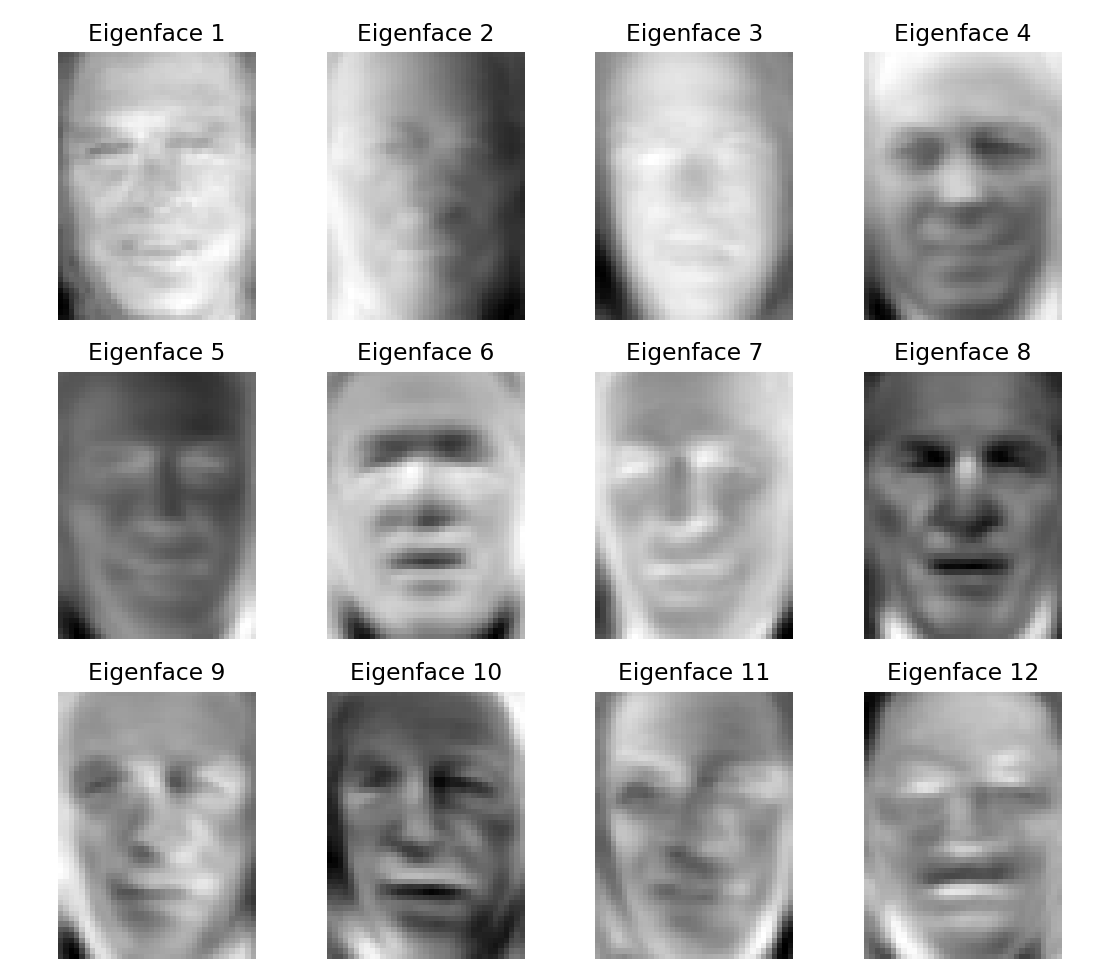

compactness.png


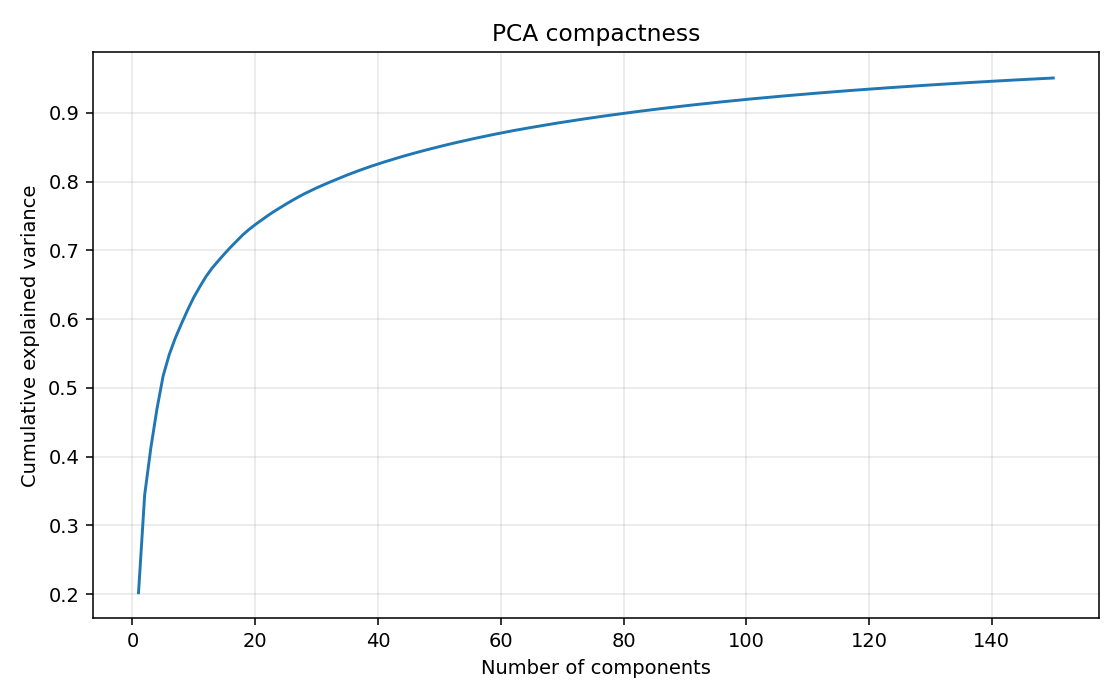

cnn_losses.png


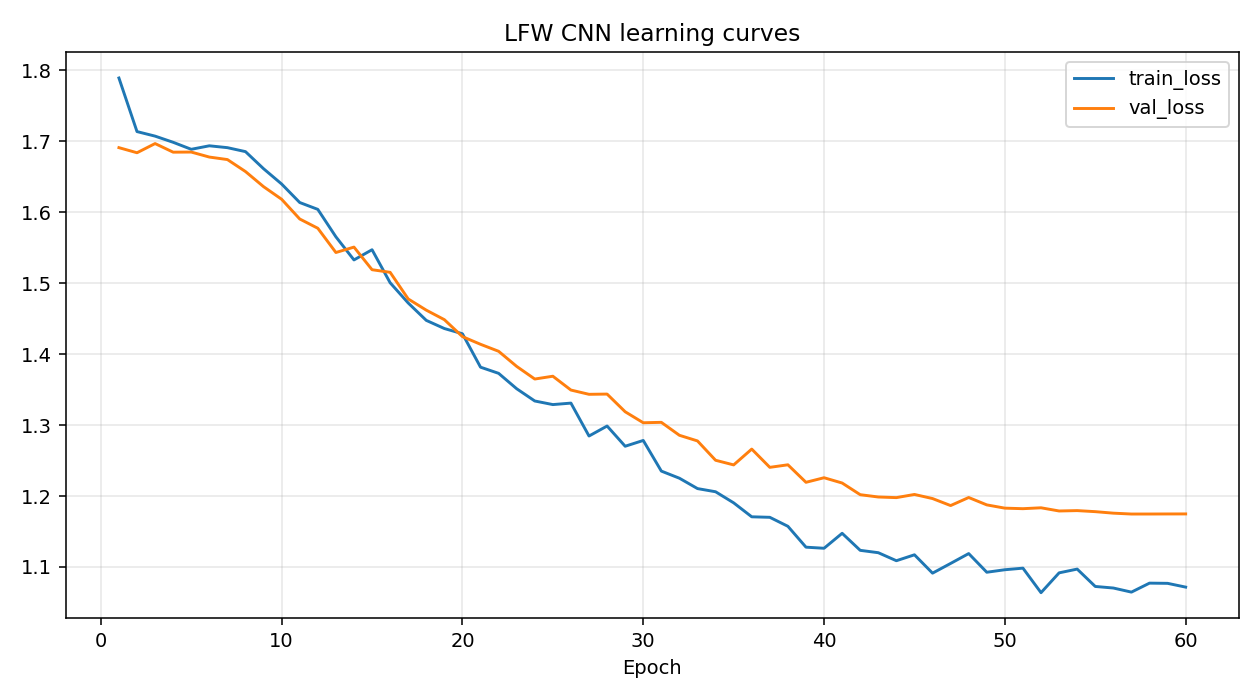

cnn_predictions.png


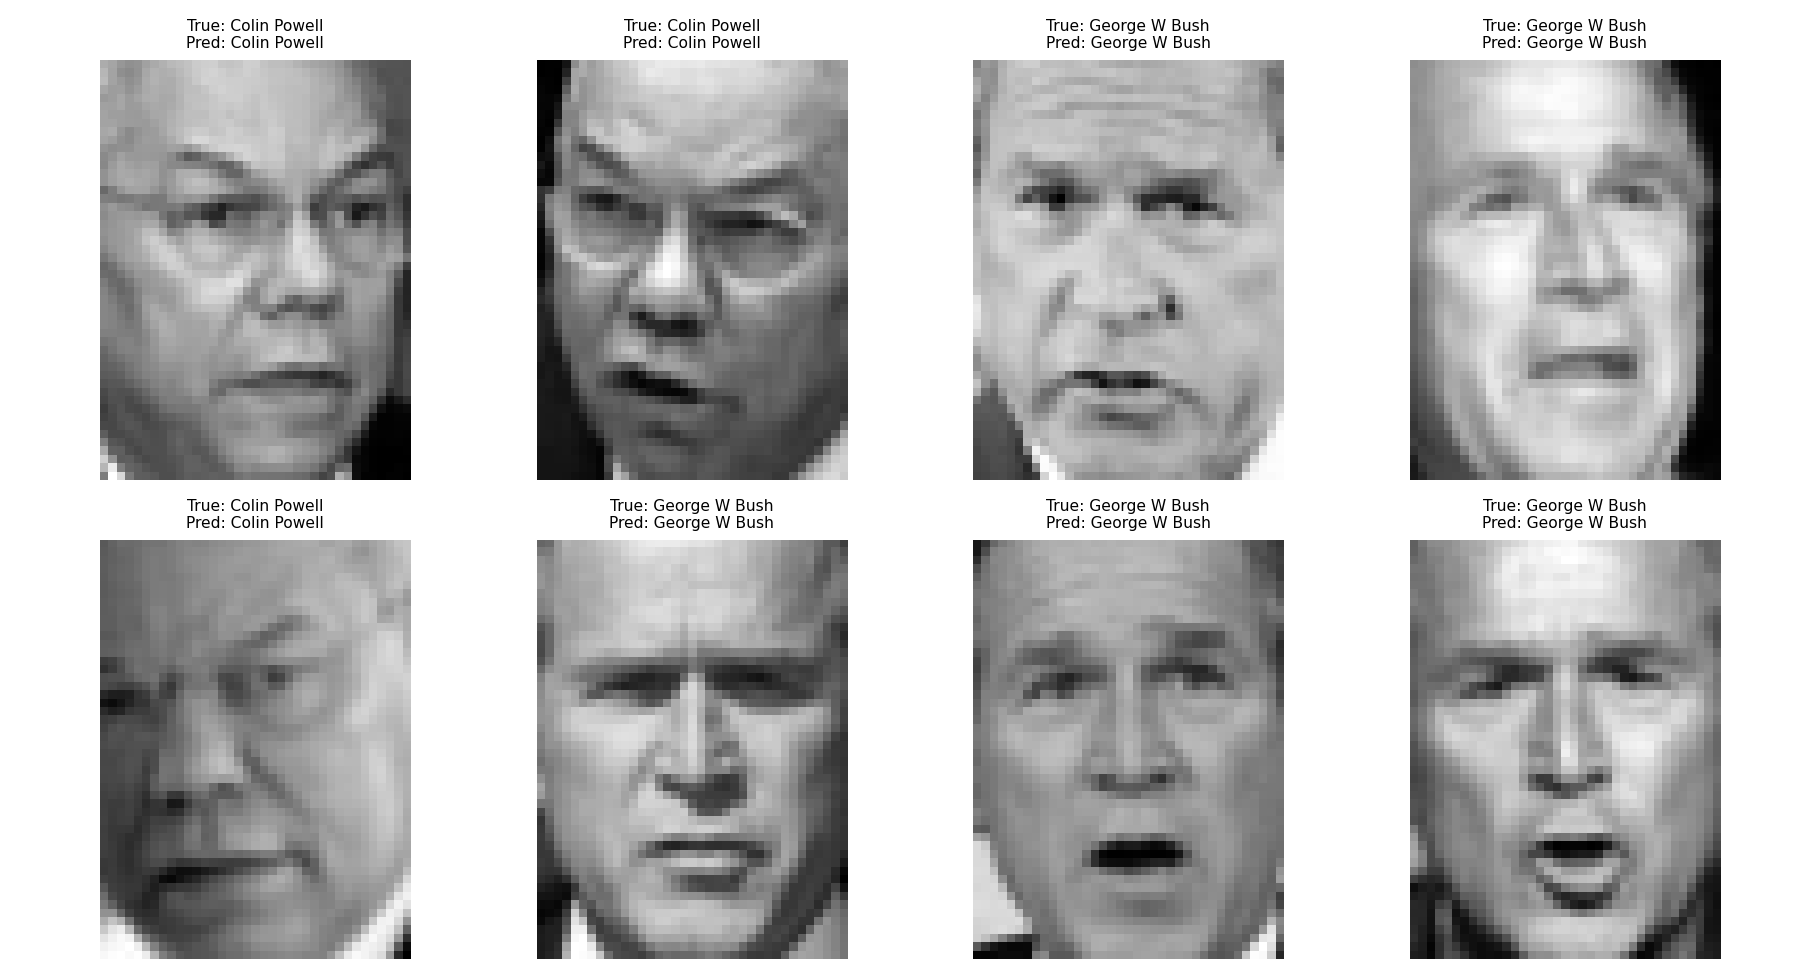

comparison.json
{
  "rf_test_accuracy": 0.6490683229813664,
  "cnn_test_accuracy": 0.6180124223602484,
  "cnn_outperformed_rf": false
}


In [21]:
if RUN_FACES:
    run("-m", "lab.faces", "--mode", "all" if MODE == "train" else "demo", "--epochs", "60", "--device", DEVICE)
    show("faces", ["eigenfaces.png", "compactness.png", "cnn_losses.png", "cnn_predictions.png", "comparison.json"])
else:
    print("FACES execution: disabled")


## Part 3.2 — CIFAR-10 with ResNet-18

## Part 3.2 — 用 ResNet-18 识别 CIFAR-10 图像

The manually implemented network contains four residual stages with [2, 2, 2, 2] blocks. A CIFAR-specific 3×3 stem preserves spatial resolution. Training uses augmented images, SGD, a OneCycle learning-rate schedule and mixed precision on CUDA.

手工实现四组残差模块，每组两个模块。输入端使用适合小图像的 3×3 卷积，保留空间分辨率。训练结合图像增强、SGD 优化器、OneCycle 学习率调度，以及 CUDA 混合精度计算。

The best validation checkpoint is evaluated on the held-out test set. Accuracy and measured training duration are reported together with the execution environment. Cluster execution is a separate experimental record.

选择验证集表现最好的模型，再在未参与训练的测试集上评估。准确率、实测训练时间与运行环境一起记录；学校集群上的运行单独记录。


### Core Implementation · 关键代码实现

**`lab/models.py` · `ResidualBlock`**

```python
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Identity() if stride == 1 and in_channels == out_channels else nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride, bias=False), nn.BatchNorm2d(out_channels))

    def forward(self, x):
        residual = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        # DEMO P3-B: 把输入的捷径分支与卷积处理后的结果相加，保留原有信息。
        # 这条较直接的路径有助于梯度向前面的层传播，使深层网络更容易训练。
        return F.relu(self.bn2(self.conv2(x)) + residual)
```


Running: /usr/bin/python3 -m lab.cifar --mode evaluate --epochs 100 --batch-size 512 --device cuda
Held-out CIFAR-10 test accuracy: 0.9524
accuracy.png


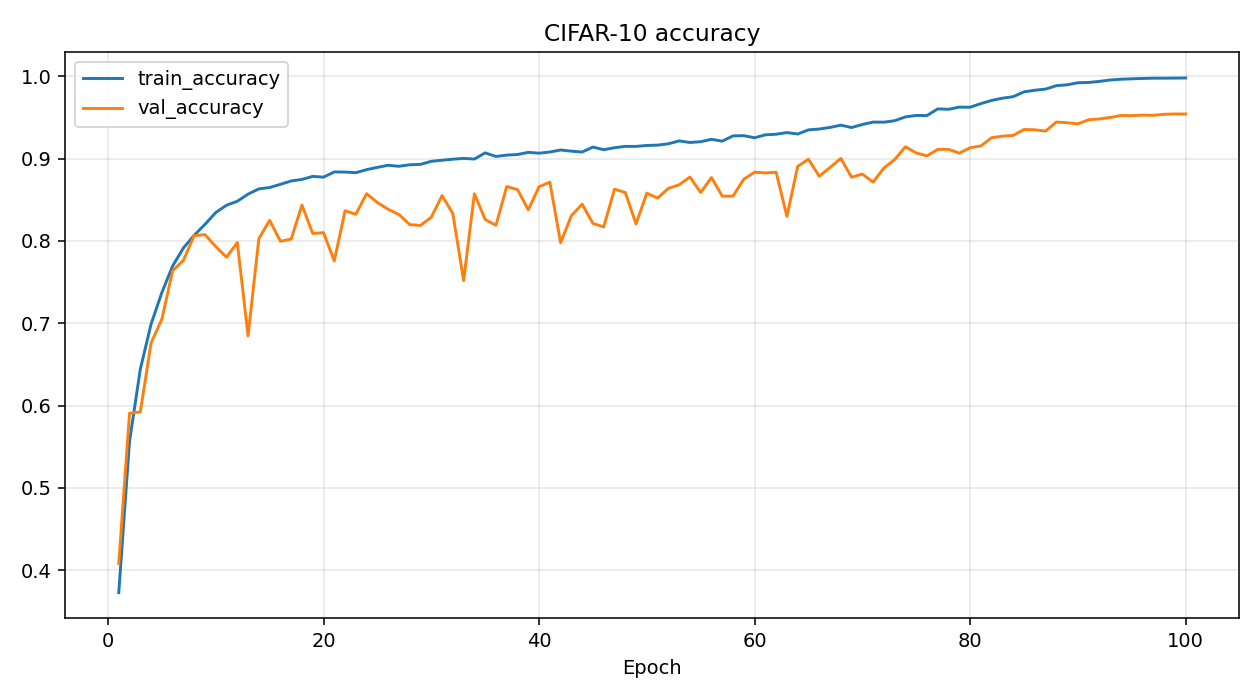

loss.png


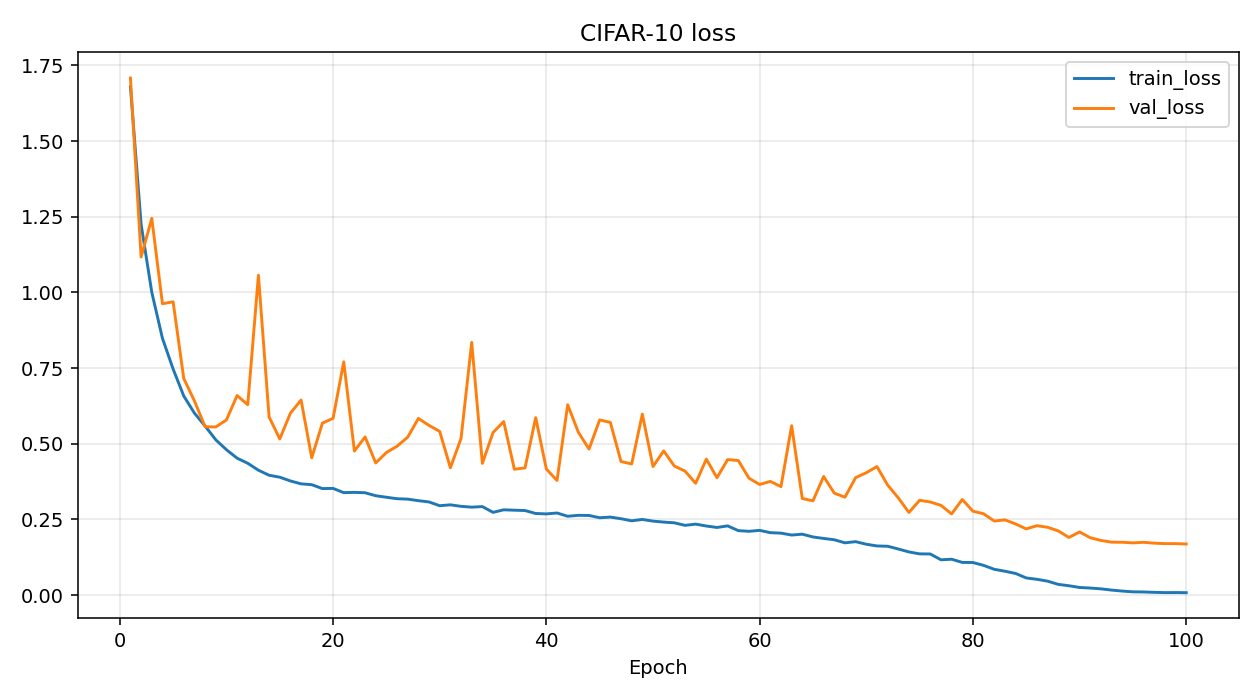

predictions.png


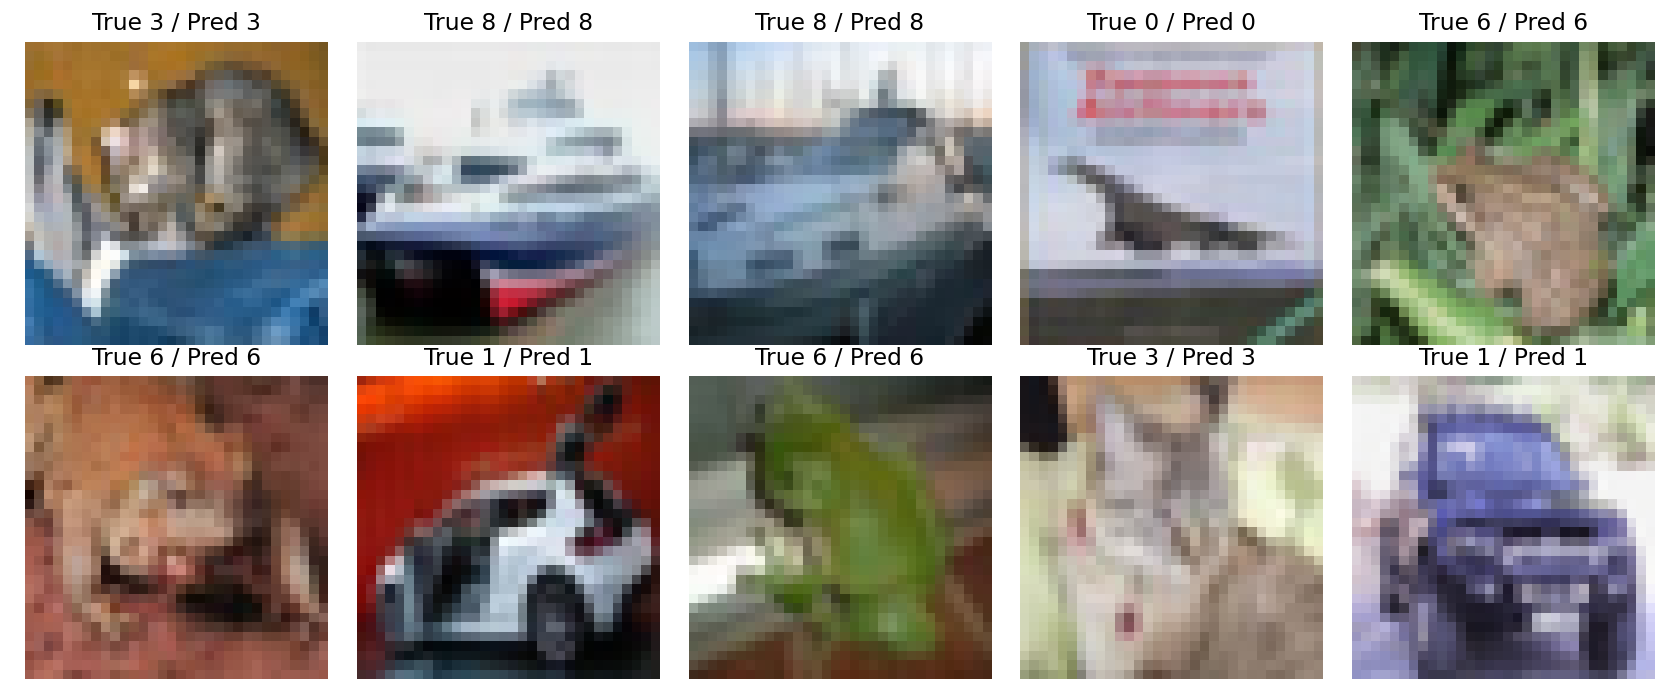

metrics.json
{
  "test_accuracy": 0.9524,
  "selected_epoch": 99,
  "inference_seconds": 1.0835110549996898,
  "train_samples": 45000,
  "test_samples": 10000,
  "environment": {
    "python": "3.13.15",
    "torch": "2.11.0+cu128",
    "numpy": "2.1.3",
    "host": "0421d0d7e253",
    "device": "cuda",
    "gpu": "Tesla T4",
    "cuda_runtime": "12.8",
    "slurm_job_id": null,
    "utc": "2026-09-13T18:34:00Z"
  },
  "smoke": false,
  "parameters": {
    "mode": "train",
    "epochs": 100,
    "batch_size": 512,
    "lr": 0.4,
    "no_amp": false,
    "device": "cuda",
    "data": "/content/COMP3710_Lab2/data/cifar10",
    "output": "/content/COMP3710_Lab2/runs/cifar",
    "smoke": false,
    "resume": false,
    "require_slurm": false
  },
  "total_training_wall_seconds": 1324.6992435920001,
  "resumed": false,
  "time_to_90_validation": 890.5574119550001,
  "time_to_94_validation": 1162.2634671880005,
  "scope": "All epochs+validation+checkpoint I/O; excludes data download/loading.

In [19]:
if RUN_CIFAR:
    run("-m", "lab.cifar", "--mode", "train" if MODE == "train" else "evaluate",
        "--epochs", CIFAR_EPOCHS, "--batch-size", CIFAR_BATCH, "--device", DEVICE, *RESUME_ARGS)
    show("cifar", ["accuracy.png", "loss.png", "predictions.png", "metrics.json"])

else:
    print("CIFAR execution: disabled")


In [ ]:
from pathlib import Path
import shutil

project = Path("/content/COMP3710_Lab2")
backup = Path("/content/drive/MyDrive/COMP3710_Lab2")

assert Path("/content/drive/MyDrive").is_dir(), "请先连接 Google Drive"
assert (project / "runs/cifar/resnet18_best.pt").is_file(), "未找到最佳模型"

backup.mkdir(parents=True, exist_ok=True)

# 如果结果本来就在 Drive 中，就不重复复制。
if (project / "runs").resolve() != (backup / "runs").resolve():
    shutil.copytree(project / "runs", backup / "runs", dirs_exist_ok=True)

# 数据也单独备份，方便以后恢复，避免再次从网上下载。
shutil.copytree(
    project / "data/cifar10",
    backup / "data/cifar10",
    dirs_exist_ok=True
)

print("备份完成：模型、实验结果和 CIFAR-10 数据已保存到 Google Drive。")

备份完成：模型、实验结果和 CIFAR-10 数据已保存到 Google Drive。


## Part 4.1 — Variational Autoencoder

## Part 4.1 — 变分自编码器（VAE）

The encoder predicts $\mu$ and $\log\sigma^2$. Reparameterisation gives $z=\mu+\sigma\odot\epsilon$, where $\epsilon\sim\mathcal{N}(0,I)$.

编码器不直接给每张图一个固定编码，而是预测均值 μ 和方差的对数 logσ²。重参数化先从标准正态分布取随机数 ε，再计算 z=μ+σ⊙ε；⊙ 表示逐元素相乘。这样既能随机采样，也能通过反向传播学习参数。

The objective combines reconstruction error and a weighted KL divergence. Results include reconstructions, a two-dimensional slice through the latent space and a PCA projection of encoded means.

训练目标由“重建误差”和“带权重的 KL 散度”组成：前者让重建图接近原图，后者鼓励潜在分布接近标准正态分布。展示内容包括原图与重建图、只改变两个潜在维度得到的图像，以及将编码均值用 PCA 压到二维后的分布。


### Core Implementation · 关键代码实现

**`lab/models.py` · `VAE.forward`**

```python
def forward(self, x):
    mu, logvar = self.encode(x)
    # DEMO P4-A: 先得到均值和方差，再加入标准正态噪声生成潜在编码 z。
        # exp(0.5*logvar) 得到标准差；训练时采样仍能传梯度，评估时用均值使重建稳定。
    z = mu + torch.exp(.5 * logvar) * torch.randn_like(mu) if self.training else mu
    return self.decode(z), mu, logvar
```

**`lab/mri.py` · `vae_loss`**

```python
def vae_loss(reconstruction, x, mu, logvar, beta):
    reconstruction_loss = F.mse_loss(reconstruction.float(), x.float())
    # DEMO P4-D: MSE 比较重建图与原图的像素差，越小表示重建越接近原图。
    # KL 鼓励潜在分布接近标准正态；beta 控制这项约束的强度。
    kl = -.5 * (1 + logvar.float() - mu.float().square() - logvar.float().exp()).mean()
    return reconstruction_loss + beta * kl, reconstruction_loss, kl
```


Running: /usr/bin/python3 -m lab.mri vae --mode demo --device cuda --data /content/COMP3710_Lab2/data
HELD-OUT TEST: {'loss': 0.0027203248704180997, 'reconstruction_mse': 0.0020885505740914274, 'kl_mean': 0.6317742782480577, 'selected_epoch': 29, 'validation_metric': {'loss': 0.0025983258882271393, 'reconstruction_mse': 0.0019505728102688278, 'kl_mean': 0.6477530717849731}, 'environment': {'python': '3.13.15', 'torch': '2.11.0+cu128', 'numpy': '2.1.3', 'host': '36135a080624', 'device': 'cuda', 'gpu': 'Tesla T4', 'cuda_runtime': '12.8', 'slurm_job_id': None, 'utc': '2026-09-14T11:04:16Z'}, 'limited_data': False, 'inference_and_plots_seconds': 8.656873202000043, 'parameters': {'task': 'vae', 'mode': 'demo', 'data': '/content/COMP3710_Lab2/data', 'output': None, 'epochs': 40, 'batch_size': 64, 'size': 64, 'base': 32, 'latent': 16, 'lr': 0.001, 'beta': 0.001, 'limit': 0, 'resume': False, 'device': 'cuda'}, 'config': {'size': 64, 'latent': 16, 'base': 32}, 'mode': 'demo'}
losses.png


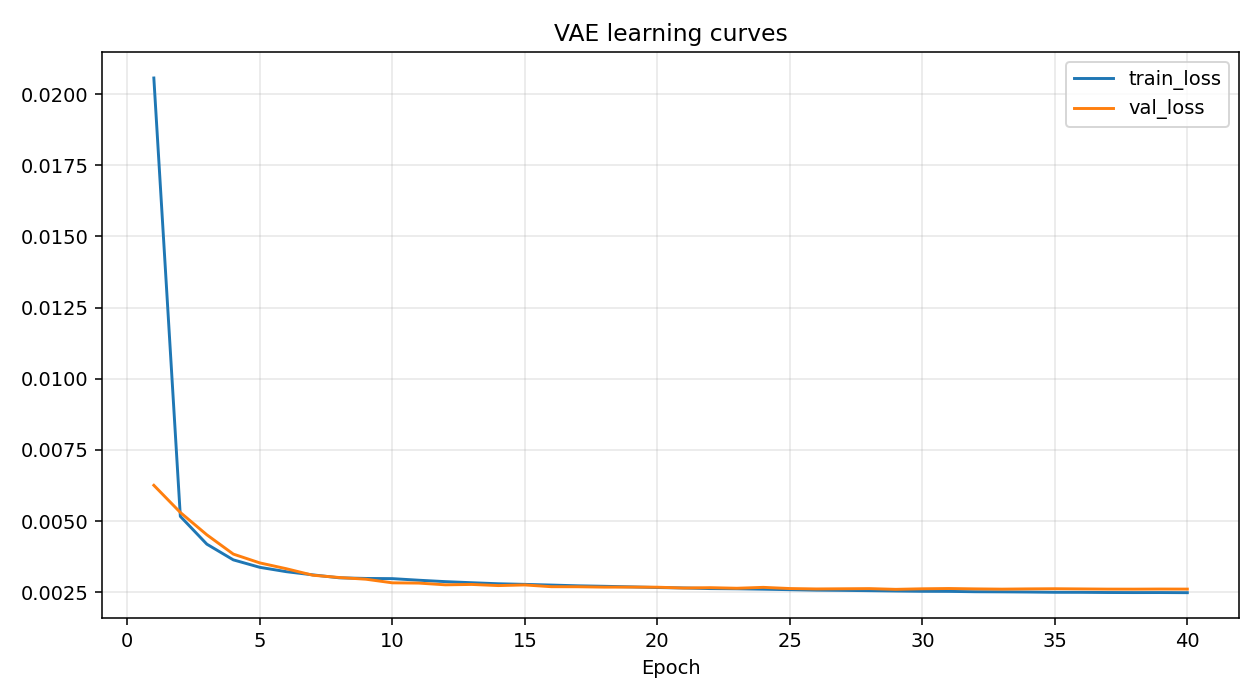

reconstructions.png


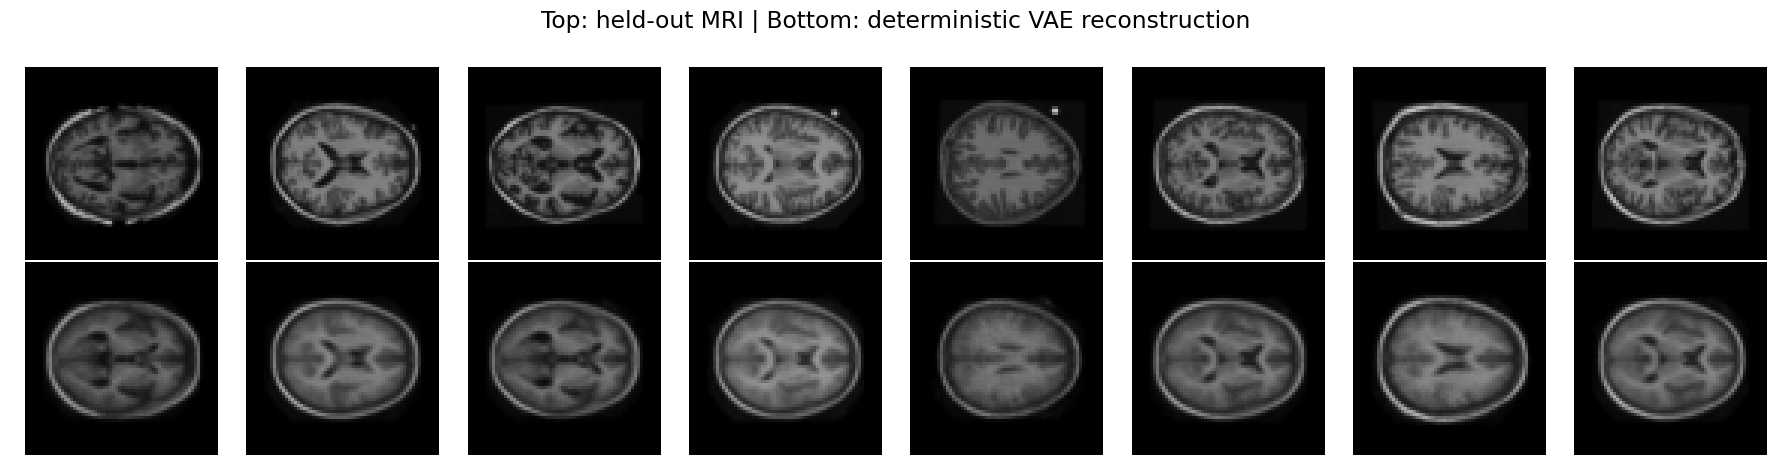

latent_manifold.png


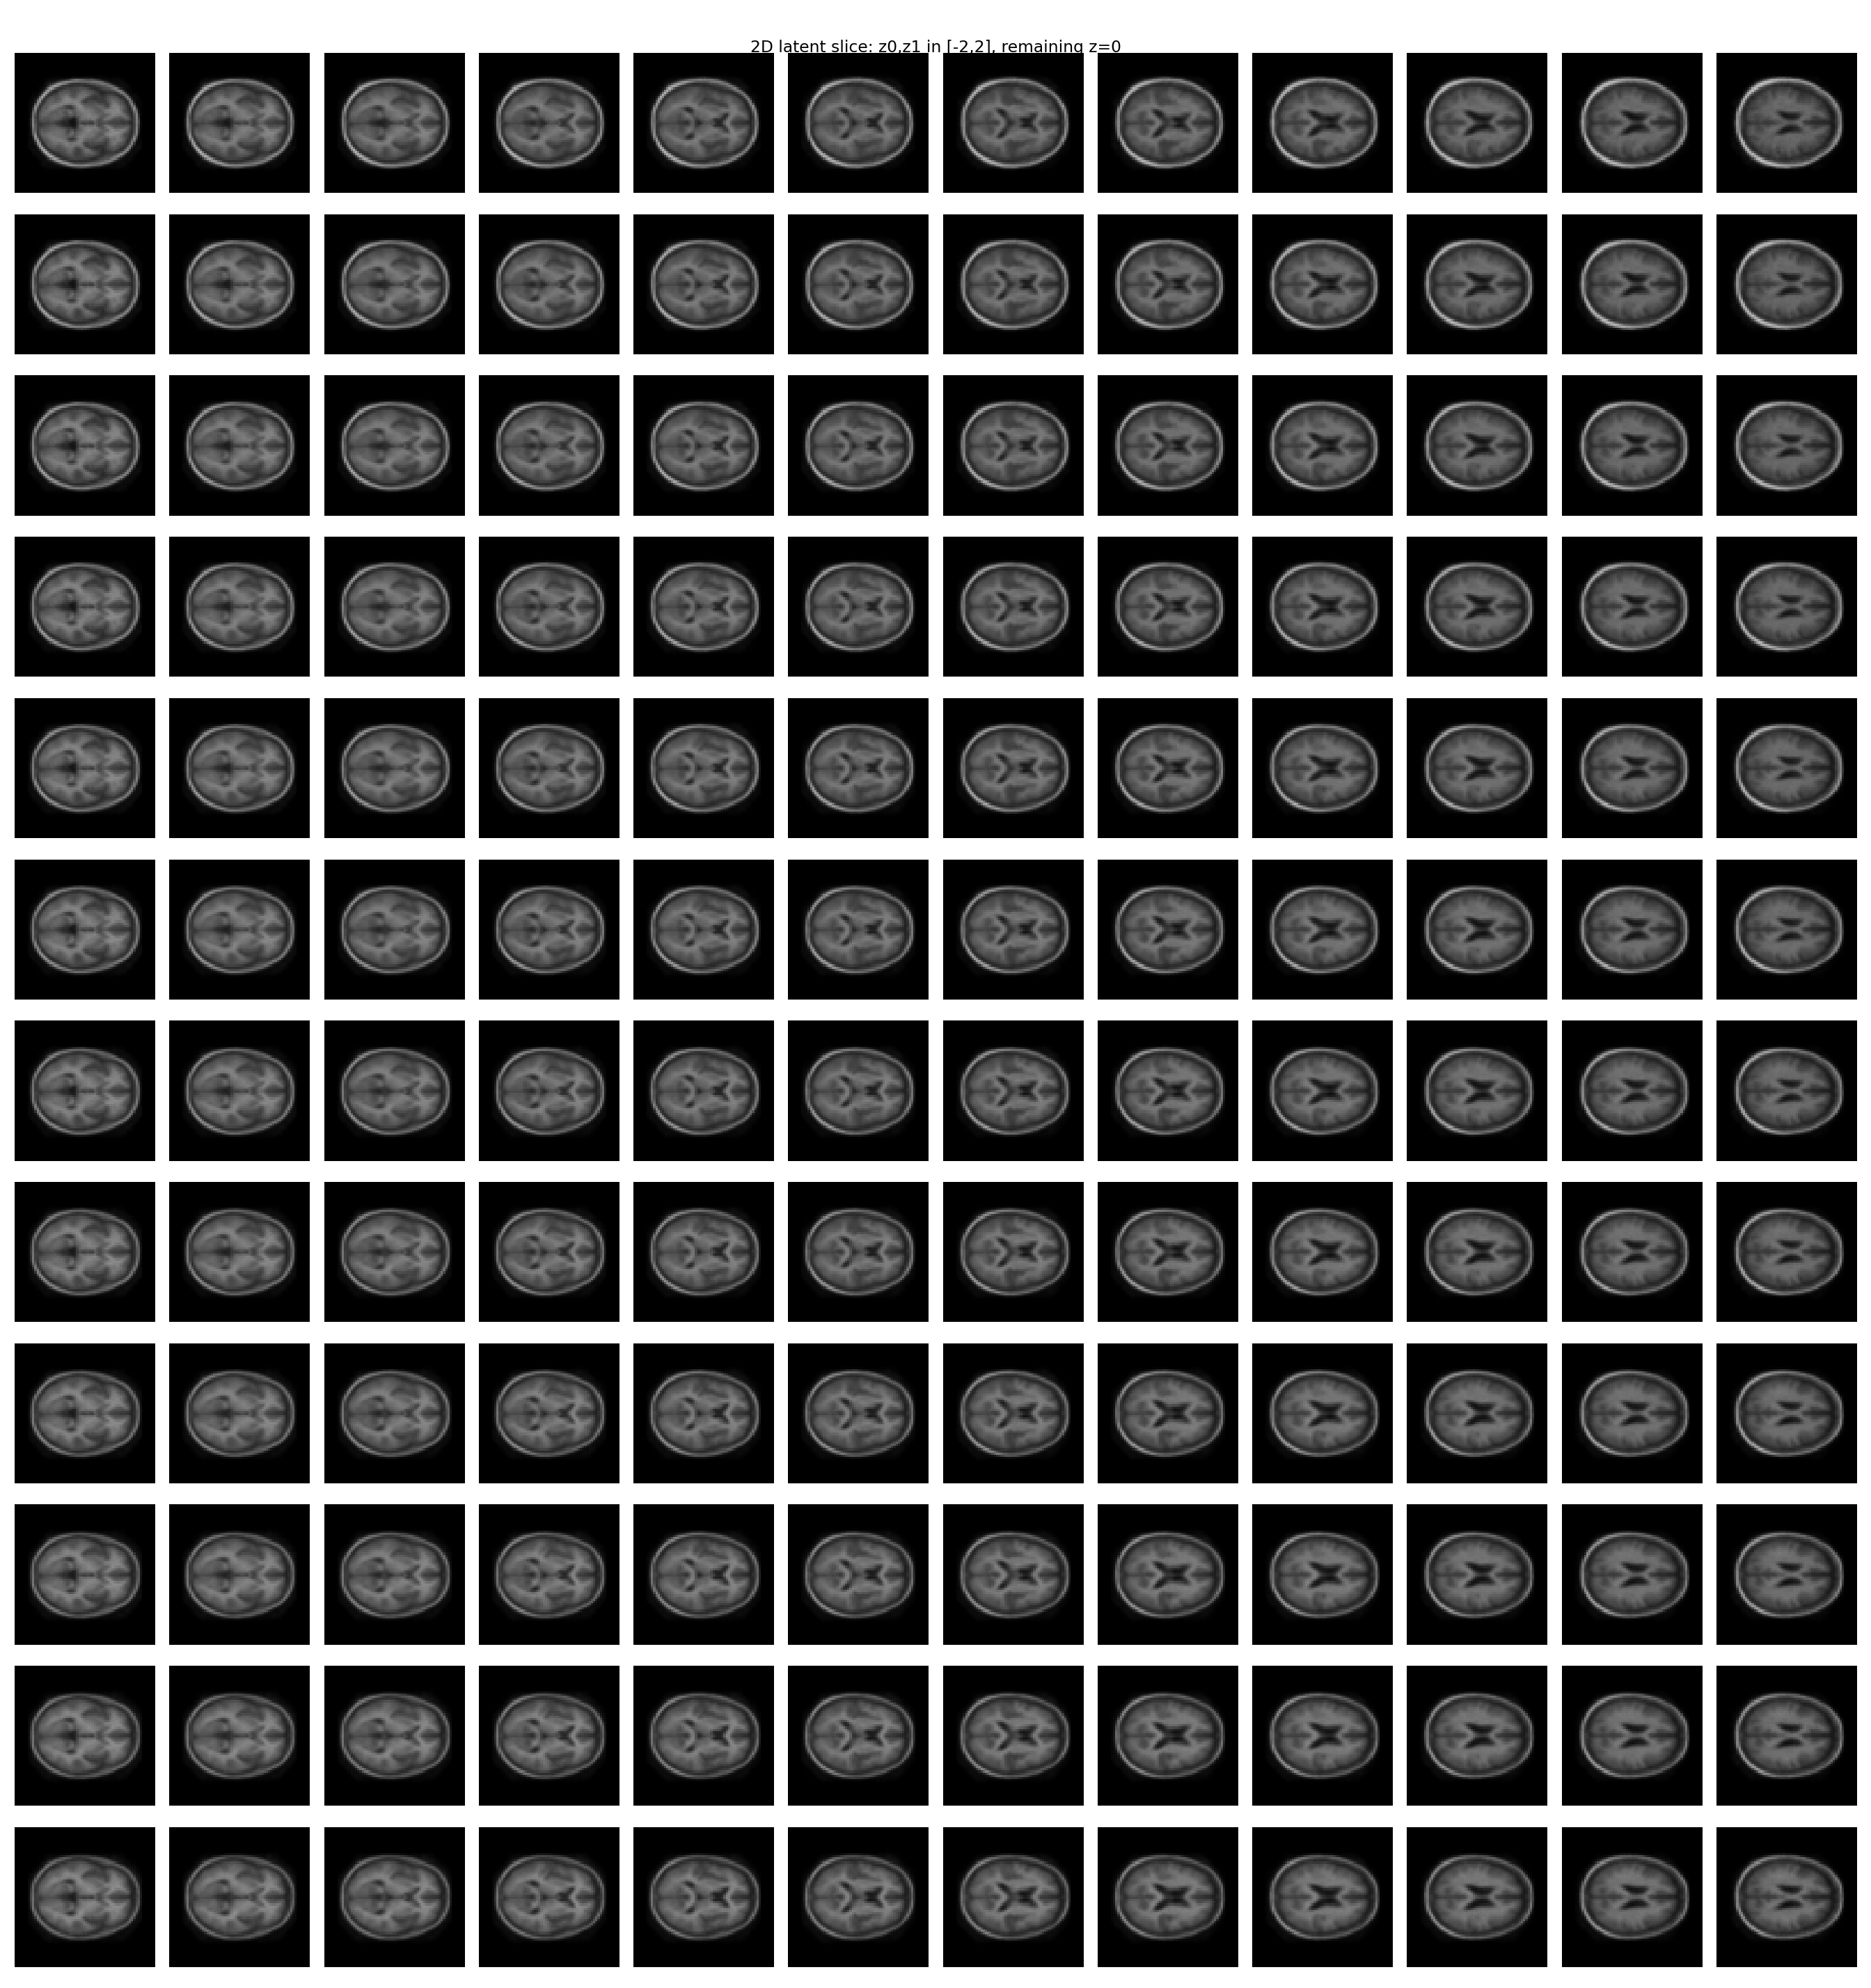

latent_projection.png


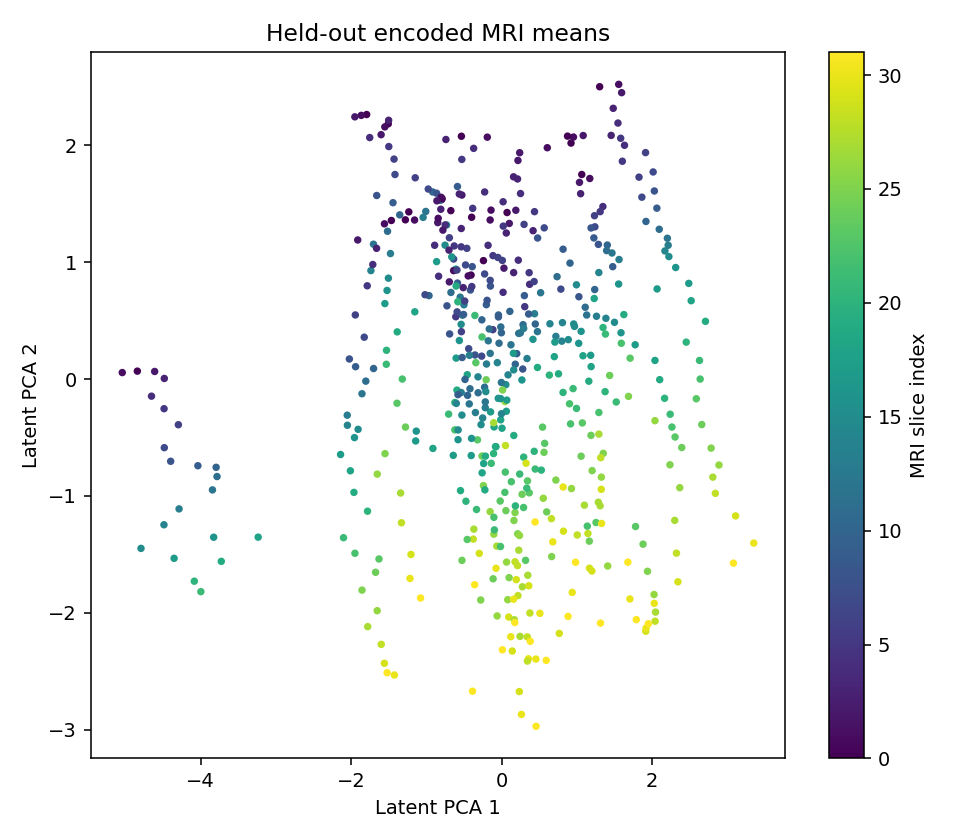

live_demo.json
{
  "loss": 0.0027203248704180997,
  "reconstruction_mse": 0.0020885505740914274,
  "kl_mean": 0.6317742782480577,
  "selected_epoch": 29,
  "validation_metric": {
    "loss": 0.0025983258882271393,
    "reconstruction_mse": 0.0019505728102688278,
    "kl_mean": 0.6477530717849731
  },
  "environment": {
    "python": "3.13.15",
    "torch": "2.11.0+cu128",
    "numpy": "2.1.3",
    "host": "36135a080624",
    "device": "cuda",
    "gpu": "Tesla T4",
    "cuda_runtime": "12.8",
    "slurm_job_id": null,
    "utc": "2026-09-14T11:04:16Z"
  },
  "limited_data": false,
  "inference_and_plots_seconds": 8.656873202000043,
  "parameters": {
    "task": "vae",
    "mode": "demo",
    "data": "/content/COMP3710_Lab2/data",
    "output": null,
    "epochs": 40,
    "batch_size": 64,
    "size": 64,
    "base": 32,
    "latent": 16,
    "lr": 0.001,
    "beta": 0.001,
    "limit": 0,
    "resume": false,
    "device": "cuda"
  },
  "config": {
    "size": 64,
    "latent": 16,
   

In [11]:
if RUN_VAE:
    run("-m", "lab.mri", "vae", "--mode", MODE, "--device", DEVICE, "--data", MRI_ROOT, *RESUME_ARGS)
    show("vae", ["losses.png", "reconstructions.png", "latent_manifold.png", "latent_projection.png", ("live_demo.json" if MODE == "demo" else "metrics.json")])
else:
    print("VAE execution: disabled")


## Part 4.2 — Brain MRI Segmentation with UNet

## Part 4.2 — 用 UNet 分割脑部 MRI

Encoder–decoder skip connections combine spatial detail with deeper features. The model predicts four categorical channels. Training combines one-hot cross-entropy with soft Dice loss.

跳跃连接把编码器保留的细节传到解码器，与更深层的特征结合。模型为每个像素输出四类分数，训练时结合 one-hot 交叉熵和 soft Dice 损失。

$$\mathrm{DSC}_c=\frac{2|P_c\cap Y_c|}{|P_c|+|Y_c|}.$$

P_c 表示被预测为类别 c 的像素，Y_c 表示真实属于类别 c 的像素。Dice 衡量两者重叠程度，越接近 1 越好；完全一致时为 1（类别非空时）。

Evaluation reports each class separately, including background. The target is DSC > 0.9 for every class. Predicted probabilities and one-hot masks are saved alongside visual comparisons.

包括背景在内，逐个类别报告 Dice，目标是每类都超过 0.9。保存四类概率、one-hot 预测标签，以及原图、真实分割和预测分割的对比图。


### Core Implementation · 关键代码实现

**`lab/models.py` · `UNet.forward`**

```python
def forward(self, x):
    skips = []
    for block in self.down:
        x = block(x)
        skips.append(x)
        x = F.max_pool2d(x, 2)
    x = self.bottleneck(x)
    for block, skip in zip(self.up, reversed(skips)):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        # DEMO P4-B: 把编码器保存的细节与解码器当前特征沿通道方向拼接。
            # 这样恢复图像尺寸时仍能利用边界细节；这里是拼接，不是残差相加。
        x = block(torch.cat([skip, x], dim=1))
    return self.output(x)  # Four categorical logits, not a single grayscale regression output.
```

**`lab/mri.py` · `segmentation_loss`**

```python
def segmentation_loss(logits, target):
    # DEMO P4-E: 把每个像素的类别变成四位 one-hot 标签，例如类别 2 对应 [0,0,1,0]。
    # 交叉熵判断类别是否正确，soft Dice 关注区域重叠；这是分类而不是预测灰度值。
    onehot = F.one_hot(target, num_classes=4).permute(0, 3, 1, 2).float()
    log_prob = F.log_softmax(logits.float(), dim=1)
    ce = -(onehot * log_prob).sum(1).mean()
    prob = log_prob.exp()
    intersection = (prob * onehot).sum((0, 2, 3))
    denominator = (prob + onehot).sum((0, 2, 3))
    dice_loss = 1 - ((2 * intersection + 1e-6) / (denominator + 1e-6)).mean()
    return .5 * ce + .5 * dice_loss
```


Running: /usr/bin/python3 -m lab.mri unet --mode demo --epochs 80 --batch-size 8 --device cuda --data /content/COMP3710_Lab2/data
HELD-OUT TEST: {'loss': 0.034130818155758524, 'dice_per_class': [0.9981172403667206, 0.9485467460835858, 0.9600047333710268, 0.9763738536533461], 'mean_dice': 0.9707606433686697, 'mean_image_dice_per_class': [0.9981200782691731, 0.9382851604810533, 0.9597770551986554, 0.9760138945763602], 'all_labels_above_0_9': True, 'confusion': [[25709969, 42518, 9321, 689], [36573, 1954657, 75527, 6], [7246, 57434, 3910298, 77940], [647, 0, 98350, 3670409]], 'samples': 544, 'note': 'Global pixel-count DSC per class; image means exclude only jointly absent classes.', 'selected_epoch': 3, 'validation_metric': {'loss': 0.033887468704155516, 'dice_per_class': [0.998296346160194, 0.9454574294509306, 0.9607523351057016, 0.9762440113085917], 'mean_dice': 0.9701875305063545, 'mean_image_dice_per_class': [0.9982990008911916, 0.9362663672438689, 0.9600794350462301, 0.9758467827524

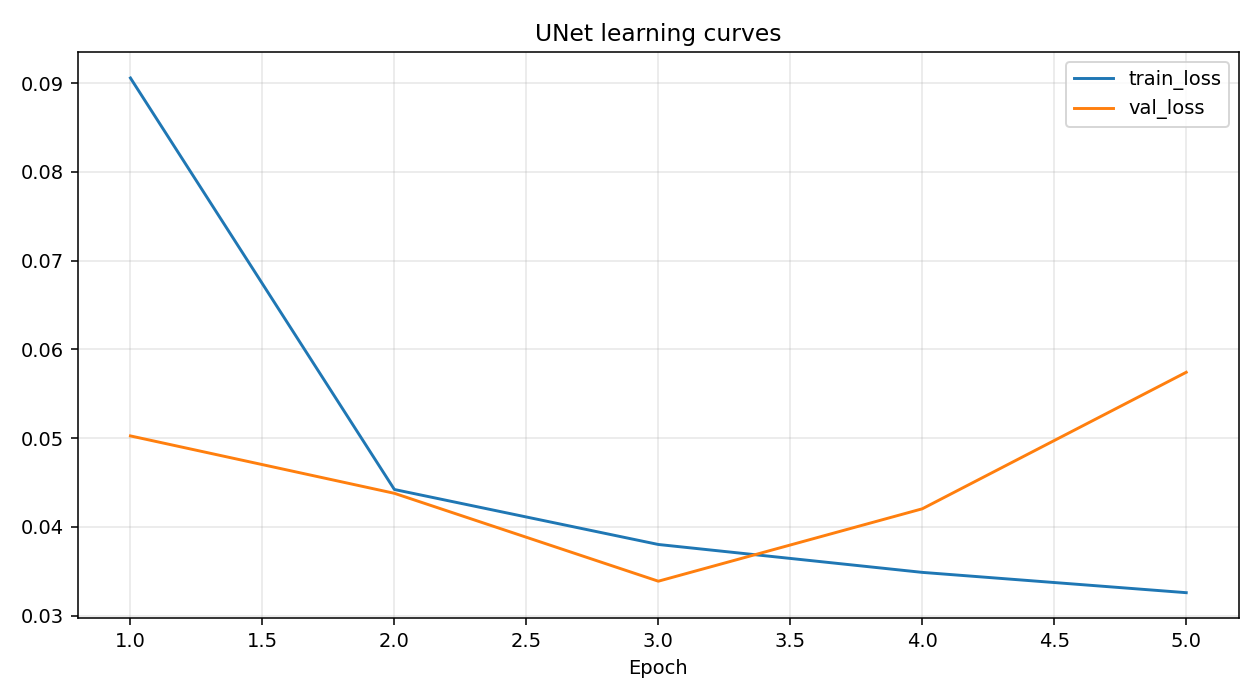

segmentations.png


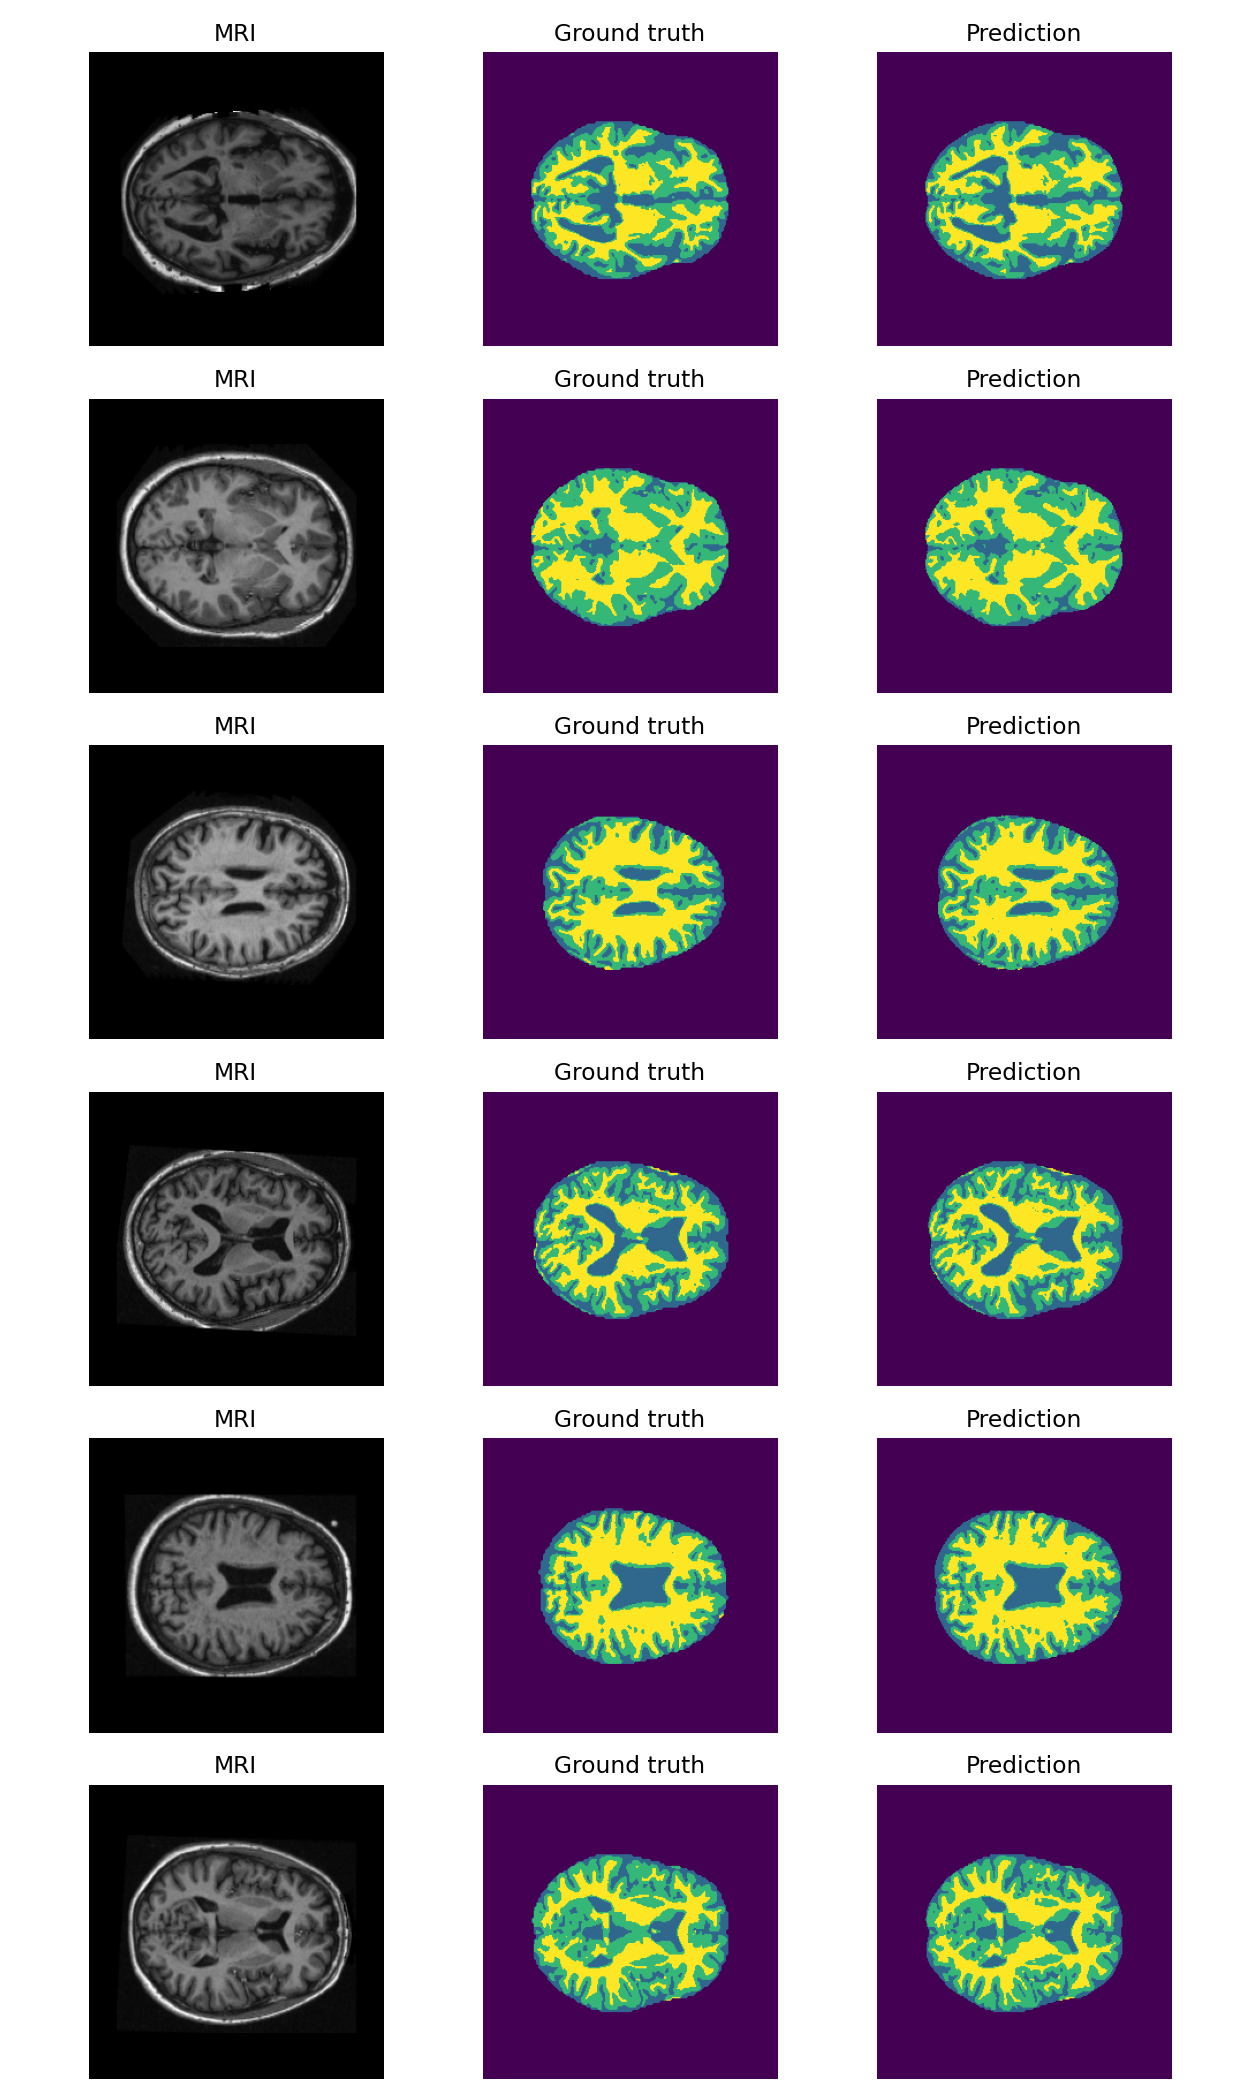

live_demo.json
{
  "loss": 0.034130818155758524,
  "dice_per_class": [
    0.9981172403667206,
    0.9485467460835858,
    0.9600047333710268,
    0.9763738536533461
  ],
  "mean_dice": 0.9707606433686697,
  "mean_image_dice_per_class": [
    0.9981200782691731,
    0.9382851604810533,
    0.9597770551986554,
    0.9760138945763602
  ],
  "all_labels_above_0_9": true,
  "confusion": [
    [
      25709969,
      42518,
      9321,
      689
    ],
    [
      36573,
      1954657,
      75527,
      6
    ],
    [
      7246,
      57434,
      3910298,
      77940
    ],
    [
      647,
      0,
      98350,
      3670409
    ]
  ],
  "samples": 544,
  "note": "Global pixel-count DSC per class; image means exclude only jointly absent classes.",
  "selected_epoch": 3,
  "validation_metric": {
    "loss": 0.033887468704155516,
    "dice_per_class": [
      0.998296346160194,
      0.9454574294509306,
      0.9607523351057016,
      0.9762440113085917
    ],
    "mean_dice": 0.970187530

In [9]:
if RUN_UNET:
    run("-m", "lab.mri", "unet", "--mode", MODE, "--epochs", UNET_EPOCHS,
        "--batch-size", UNET_BATCH, "--device", DEVICE, "--data", MRI_ROOT, *RESUME_ARGS)
    show("unet", ["losses.png", "segmentations.png", ("live_demo.json" if MODE == "demo" else "metrics.json")])
else:
    print("UNET execution: disabled")


Running: /usr/bin/python3 -m lab.mri unet --mode demo --device cuda --data /content/COMP3710_Lab2/data --batch-size 8
HELD-OUT TEST: {'loss': 0.03413085510735126, 'dice_per_class': [0.9981173764270962, 0.9485511634949104, 0.9600041343329221, 0.9763716878426077], 'mean_dice': 0.9707610905243841, 'mean_image_dice_per_class': [0.9981202150092405, 0.9382904495167381, 0.9597764597000444, 0.9760118148782674], 'all_labels_above_0_9': True, 'confusion': [[25709975, 42513, 9320, 689], [36571, 1954668, 75518, 6], [7247, 57432, 3910297, 77942], [647, 0, 98364, 3670395]], 'samples': 544, 'note': 'Global pixel-count DSC per class; image means exclude only jointly absent classes.', 'selected_epoch': 3, 'validation_metric': {'loss': 0.033887468704155516, 'dice_per_class': [0.998296346160194, 0.9454574294509306, 0.9607523351057016, 0.9762440113085917], 'mean_dice': 0.9701875305063545, 'mean_image_dice_per_class': [0.9982990008911916, 0.9362663672438689, 0.9600794350462301, 0.9758467827524457], 'all_la

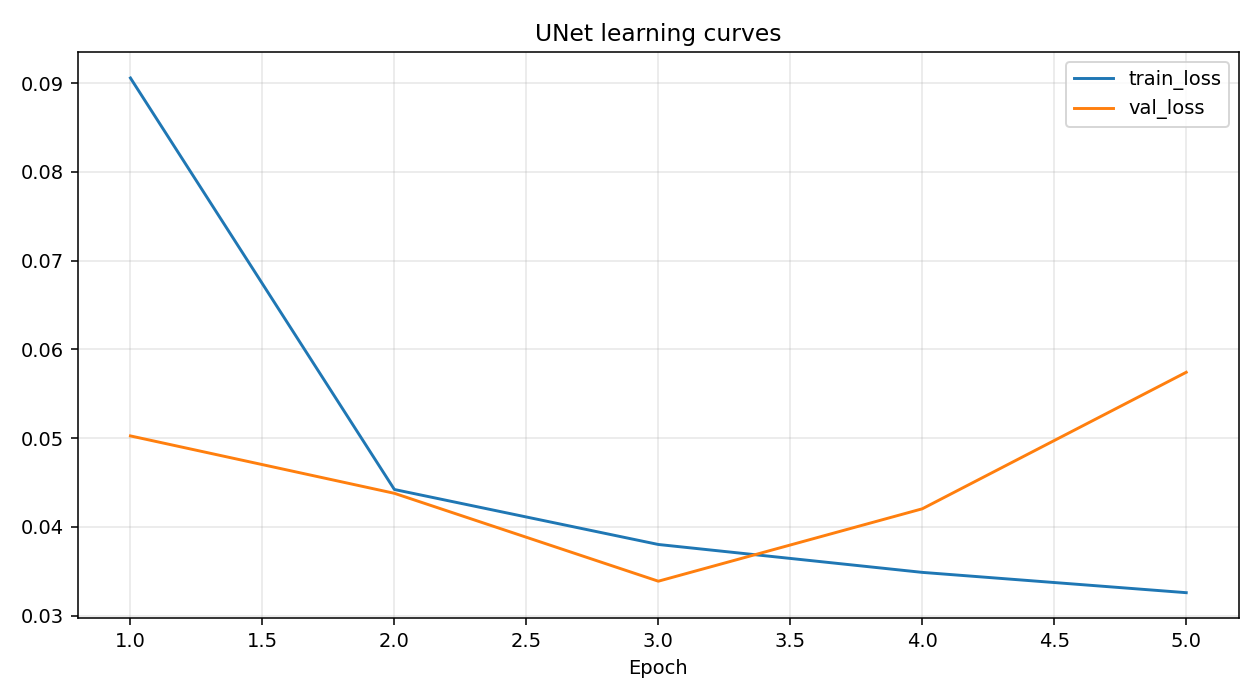

segmentations.png


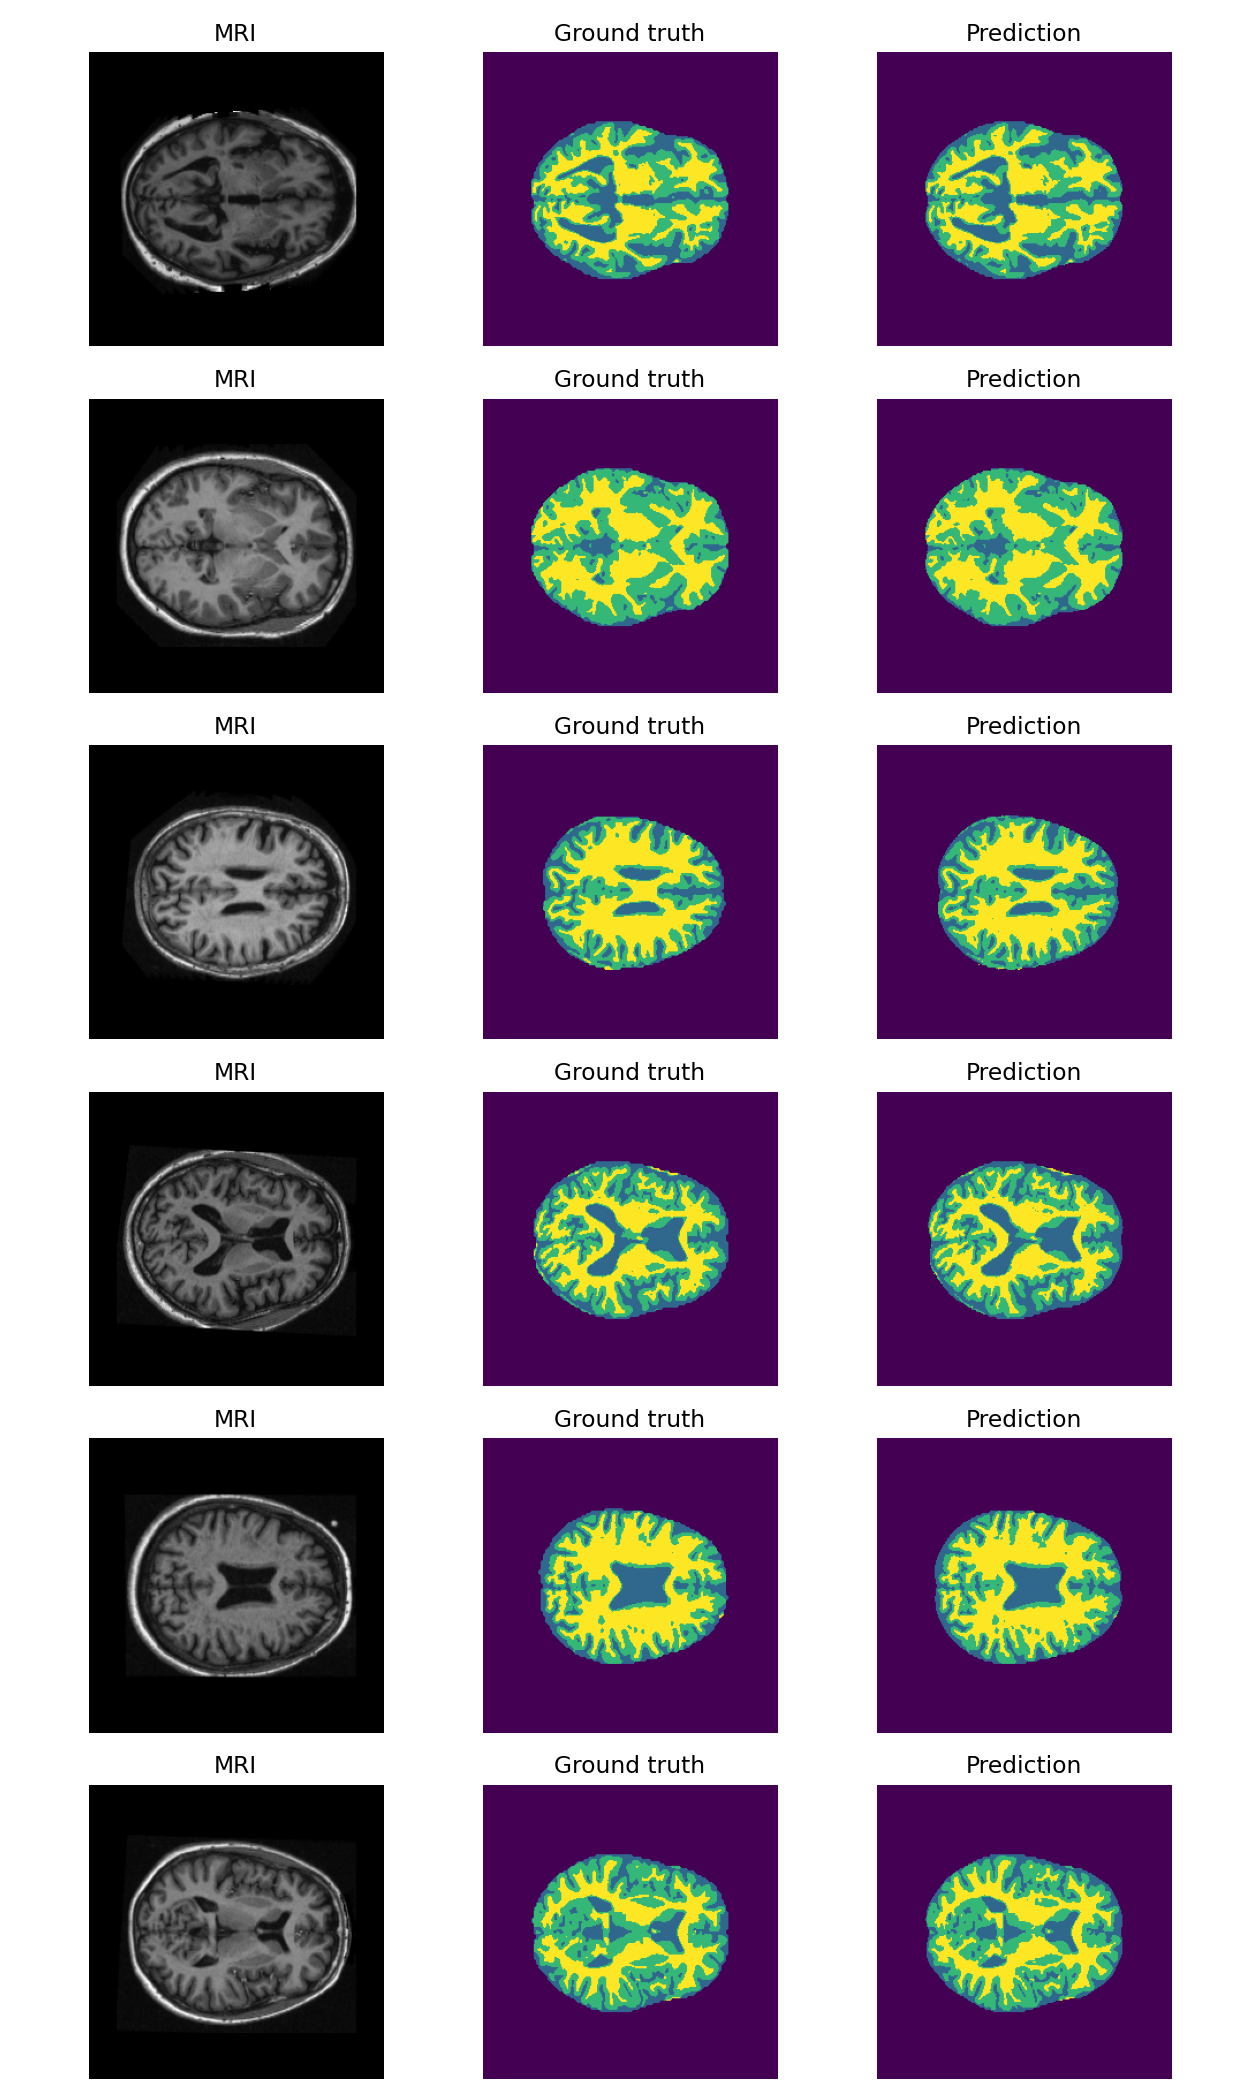

live_demo.json
{
  "loss": 0.03413085510735126,
  "dice_per_class": [
    0.9981173764270962,
    0.9485511634949104,
    0.9600041343329221,
    0.9763716878426077
  ],
  "mean_dice": 0.9707610905243841,
  "mean_image_dice_per_class": [
    0.9981202150092405,
    0.9382904495167381,
    0.9597764597000444,
    0.9760118148782674
  ],
  "all_labels_above_0_9": true,
  "confusion": [
    [
      25709975,
      42513,
      9320,
      689
    ],
    [
      36571,
      1954668,
      75518,
      6
    ],
    [
      7247,
      57432,
      3910297,
      77942
    ],
    [
      647,
      0,
      98364,
      3670395
    ]
  ],
  "samples": 544,
  "note": "Global pixel-count DSC per class; image means exclude only jointly absent classes.",
  "selected_epoch": 3,
  "validation_metric": {
    "loss": 0.033887468704155516,
    "dice_per_class": [
      0.998296346160194,
      0.9454574294509306,
      0.9607523351057016,
      0.9762440113085917
    ],
    "mean_dice": 0.9701875305

In [ ]:
#@title Maintenance Record · 环境与备份记录
RUN_MAINTENANCE = False #@param {type:"boolean"}
if RUN_MAINTENANCE:
    import json
    import psutil
    from lab.common import curves

    # 确保先前的 UNet 训练子进程已停止，释放 GPU。
    for process in psutil.process_iter(["cmdline"]):
        args = process.info["cmdline"] or []
        if (
            "lab.mri" in args and "unet" in args
            and "--mode" in args
            and args[args.index("--mode") + 1] == "train"
        ):
            process.terminate()
            process.wait(timeout=30)

    # 用已完成的训练记录生成曲线。
    history = json.loads(
        (PROJECT / "runs/unet/history.json").read_text()
    )
    curves(
        history, PROJECT / "runs/unet/losses.png",
        ["train_loss", "val_loss"], "UNet learning curves"
    )

    # 加载验证集选出的最佳模型，对独立测试集进行评估。
    run(
        "-m", "lab.mri", "unet", "--mode", "demo",
        "--device", DEVICE, "--data", MRI_ROOT,
        "--batch-size", "8"
    )
    show("unet", ["losses.png", "segmentations.png", "live_demo.json"])


In [ ]:
#@title Maintenance Record · 环境与备份记录
RUN_MAINTENANCE = False #@param {type:"boolean"}
if RUN_MAINTENANCE:
    from pathlib import Path
    import torch

    project = Path("/content/COMP3710_Lab2")

    print("GPU 可用：", torch.cuda.is_available())
    print("项目源码存在：", (project / "lab/mri.py").is_file())
    print("UNet 最佳模型存在：",
          (project / "runs/unet/unet_best.pt").is_file())
    print("Drive 已连接：",
          Path("/content/drive/MyDrive").is_dir())
    print("MRI 数据目录存在：",
          (project / "data/keras_png_slices_data").is_dir())


GPU 可用： True
项目源码存在： False
UNet 最佳模型存在： False
Drive 已连接： False
MRI 数据目录存在： False


## Part 4.3 — Brain MRI Synthesis with DCGAN

## Part 4.3 — 用 DCGAN 生成脑部 MRI

The generator maps random latent vectors to 64×64 images; the discriminator distinguishes real and generated slices. Separate optimisation steps use binary cross-entropy with logits.

生成器把随机潜在向量变成 64×64 图像，判别器判断输入是真实切片还是生成图像。两者分开更新参数，使用直接接收原始分数的二元交叉熵损失。

Fixed-noise samples track training evolution. Fresh samples and latent interpolations assess diversity. Nearest-training-image comparisons provide an additional similarity diagnostic; loss alone does not establish realism or exclude mode collapse.

固定同一批随机输入，观察生成图随训练如何变化；另外生成新样本，并在潜在向量之间插值，观察多样性。与最相似训练图比较可辅助检查相似程度，但损失下降并不等于图像逼真，也不能单靠它排除“模式崩塌”（不同随机输入生成很相似的图）。


### Core Implementation · 关键代码实现

**`lab/models.py` · `Generator`**

```python
class Generator(nn.Module):
    def __init__(self, latent=100, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent, base * 8, 4, 1, 0, bias=False), nn.BatchNorm2d(base * 8), nn.ReLU(),
            nn.ConvTranspose2d(base * 8, base * 4, 4, 2, 1, bias=False), nn.BatchNorm2d(base * 4), nn.ReLU(),
            nn.ConvTranspose2d(base * 4, base * 2, 4, 2, 1, bias=False), nn.BatchNorm2d(base * 2), nn.ReLU(),
            nn.ConvTranspose2d(base * 2, base, 4, 2, 1, bias=False), nn.BatchNorm2d(base), nn.ReLU(),
            nn.ConvTranspose2d(base, 1, 4, 2, 1), nn.Tanh())

    def forward(self, z):
        return self.net(z)
```


Running: /usr/bin/python3 -m lab.mri gan --mode demo --device cuda --data /content/COMP3710_Lab2/data
GAN samples saved. Inspect realism, diversity and nearest-training comparisons: /content/COMP3710_Lab2/runs/gan
losses.png


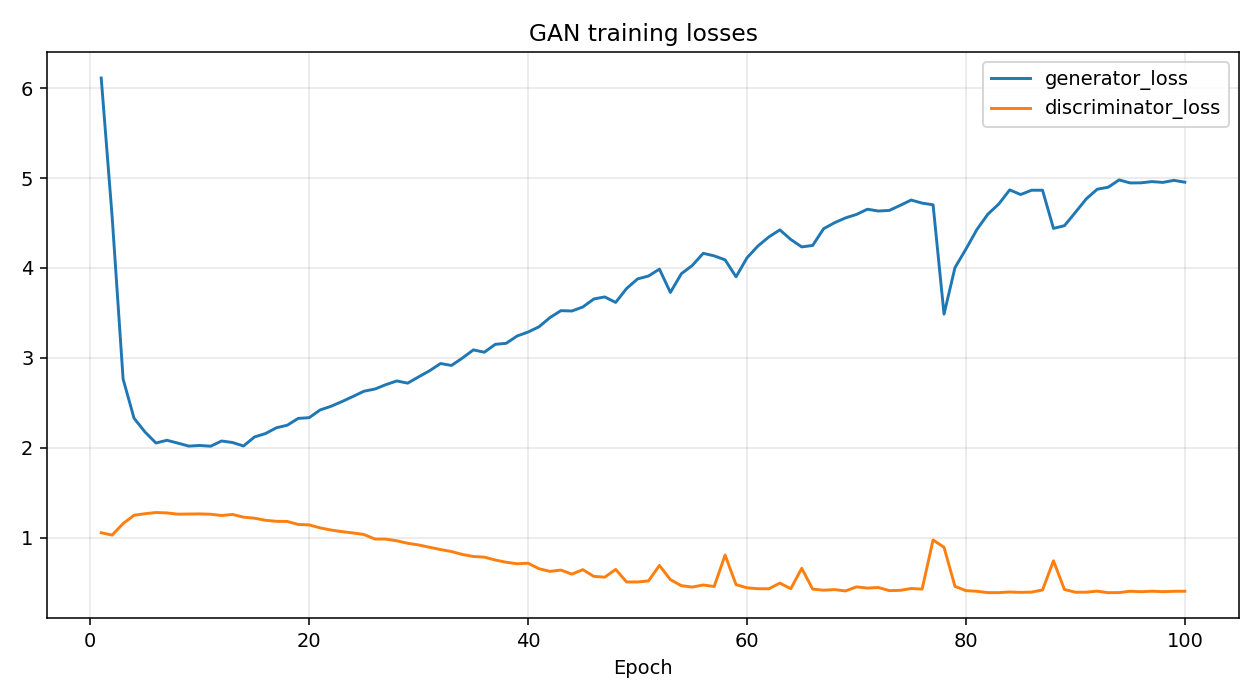

generated.png


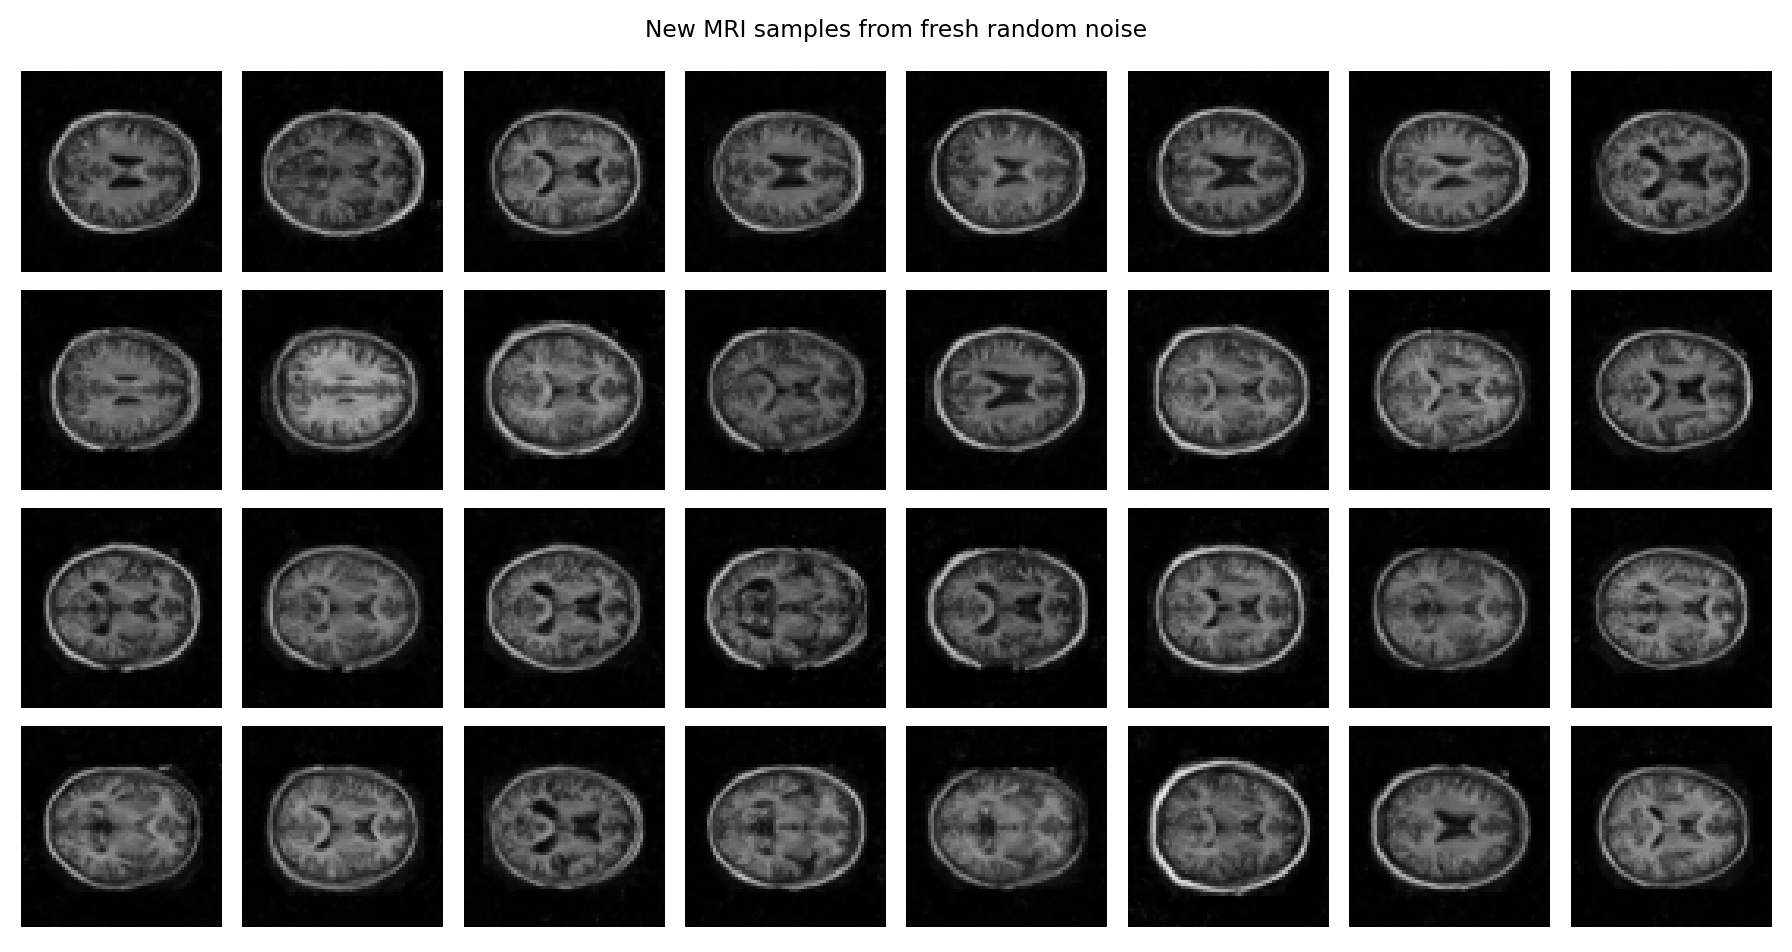

interpolation.png


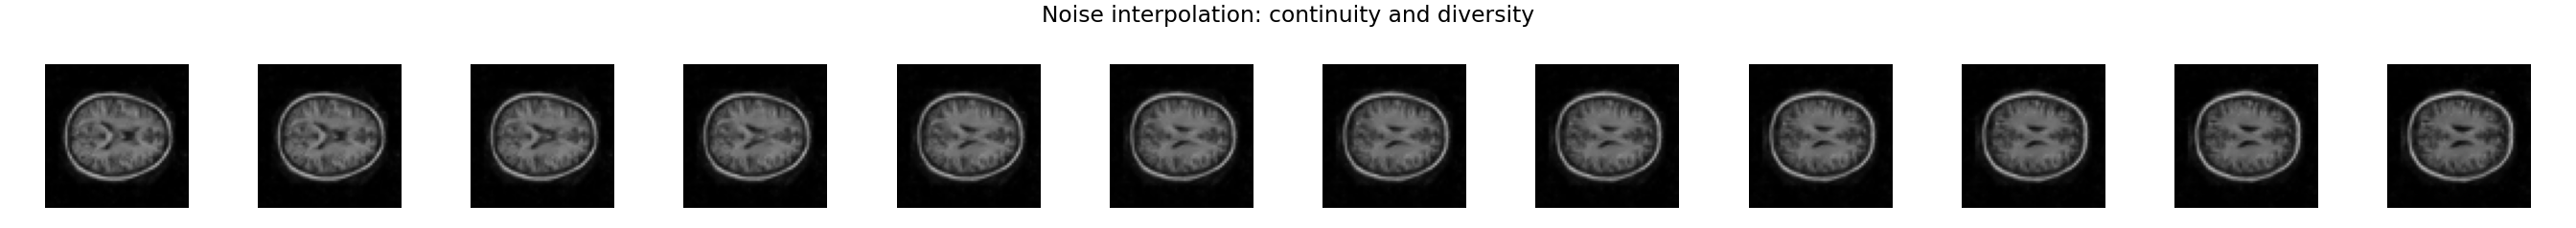

nearest_training_examples.png


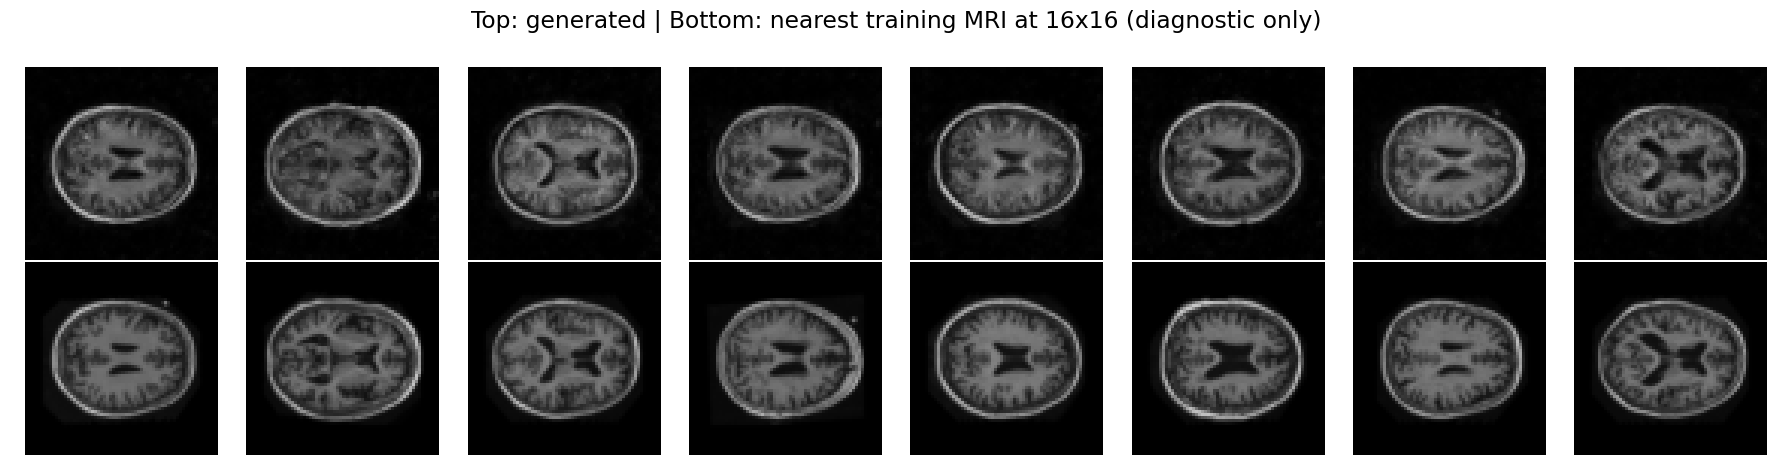

live_demo.json
{
  "environment": {
    "python": "3.13.15",
    "torch": "2.11.0+cu128",
    "numpy": "2.1.3",
    "host": "36135a080624",
    "device": "cuda",
    "gpu": "Tesla T4",
    "cuda_runtime": "12.8",
    "slurm_job_id": null,
    "utc": "2026-09-14T11:06:35Z"
  },
  "selected_epoch": 100,
  "actual_model_config": {
    "latent": 100,
    "base": 64,
    "size": 64
  },
  "limited_data": false,
  "generated_count": 32,
  "pairwise_thumbnail_rmse_mean": 0.060062870383262634,
  "nearest_training_thumbnail_rmse": [
    0.02390771359205246,
    0.03291453421115875,
    0.027439970523118973,
    0.02683180756866932,
    0.02904689870774746,
    0.029704123735427856,
    0.026318470016121864,
    0.025396492332220078,
    0.024124564602971077,
    0.028562171384692192,
    0.03085319511592388,
    0.029392436146736145,
    0.029674511402845383,
    0.02665063552558422,
    0.024574894458055496,
    0.02524377405643463,
    0.028830179944634438,
    0.021698834374547005,
    0.030

In [12]:
if RUN_GAN:
    run("-m", "lab.mri", "gan", "--mode", MODE, "--device", DEVICE, "--data", MRI_ROOT, *RESUME_ARGS)
    show("gan", ["losses.png", "generated.png", "interpolation.png", "nearest_training_examples.png", ("live_demo.json" if MODE == "demo" else "metrics.json")])
else:
    print("GAN execution: disabled")


## Implementation Reference

## 关键函数参考

Selected functions from the source modules used by the experiments.

展示实验实际调用的源码函数，便于对应模型结构、计算步骤与结果。


In [ ]:
import inspect
from lab import part1, faces, models, mri, cifar, data
TOPIC = "P1 Fourier" #@param ["P1 Fourier", "P1 DFT", "P1 Timing", "P2 PCA", "P3 FaceCNN", "P3 ResNet", "P3 AMP", "P4 VAE", "P4 UNet", "P4 OneHot", "P4 Dice", "P4 GAN", "P4 Data"]
target = {"P1 Fourier": part1.square_wave_fourier, "P1 DFT": part1.naive_dft_torch,
          "P1 Timing": part1.timed, "P2 PCA": faces.pca_rf, "P3 FaceCNN": models.FaceCNN,
          "P3 ResNet": models.ResidualBlock, "P3 AMP": cifar.train_epoch, "P4 VAE": models.VAE,
          "P4 UNet": models.UNet, "P4 OneHot": mri.segmentation_loss, "P4 Dice": mri.dice_from_confusion,
          "P4 GAN": mri.gan, "P4 Data": data.MRIDataset}[TOPIC]
print(inspect.getsource(target))


## Experimental Results

## 实验结果

The table below reflects saved outputs from the current project. Missing results are recorded as not available.

下表只反映当前项目已有的结果文件；缺失的结果标为 Not available（尚无结果），文件存在本身不代表指标达标。


### Recorded Outcomes · 已记录的实验结果

| Experiment / 实验 | Observed result / 实测结果 | Interpretation / 说明 |
|---|---|---|
| Fourier / 傅里叶 | Explicit GPU DFT agrees with NumPy FFT / GPU 显式 DFT 通过一致性检查 | T4; four input sizes / 四种输入规模 |
| LFW Random Forest / 随机森林 | Test accuracy 64.91% / 测试准确率 64.91% | PCA features / PCA 特征 |
| LFW CNN / 人脸卷积网络 | Test accuracy 61.80% / 测试准确率 61.80% | Did not exceed RF in this run / 本次未超过随机森林 |
| CIFAR-10 ResNet-18 | Test accuracy 95.24%; training 1324.70 s / 测试准确率 95.24%，训练约 22 分钟 | T4; 360-second condition not met / 未达到 360 秒条件 |
| MRI VAE | Test reconstruction MSE 0.002089 / 测试重建均方误差 | Validation-selected epoch 29 / 验证集选择第 29 轮 |
| MRI UNet | Test Dice: 0.9981, 0.9486, 0.9600, 0.9764 | 544 test slices; checkpoint 3 / 544 张测试切片，第 3 轮模型 |
| MRI GAN | 100 epochs; fresh samples, interpolation and similarity diagnostics / 100 轮，生成、插值与相似性检查 | Realism and absence of collapse are not automatically certified / 未自动认证真实性及无模式崩塌 |

UNet training was stopped after five completed epochs based on validation performance. The selected checkpoint was evaluated on the independent test partition. The configured 80-epoch maximum is not a claim of 80 completed epochs. The GAN checkpoint is the final epoch, not an automatically selected optimum.

UNet 根据验证表现，在完成五轮后提前停止，并使用验证集选出的模型进行独立测试。配置中的 80 轮是原定上限，并非实际完成轮数。GAN 使用最后一轮模型，不代表自动选出的最优模型。

These records describe Colab runs. Rangpur execution and course completion records are separate evidence.

以上为 Colab 运行记录，Rangpur 运行及课程完成情况需另行记录。


In [ ]:
from html import escape
rows = []
for experiment, filename in [("Fourier", "part1/metrics.json"), ("Faces", "faces/comparison.json"),
                             ("CIFAR-10", "cifar/metrics.json"), ("VAE", "vae/metrics.json"),
                             ("UNet", "unet/metrics.json"), ("GAN", "gan/metrics.json")]:
    result_path = PROJECT / "runs" / filename
    if not result_path.exists():
        result_path = result_path.with_name("live_demo.json")
    status = "Available" if result_path.exists() else "Not available"
    rows.append(f"<tr><td>{escape(experiment)}</td><td>{status}</td><td>{escape(filename)}</td></tr>")
display(HTML("<table><tr><th>Experiment</th><th>Saved output</th><th>Record</th></tr>" + "".join(rows) + "</table>"))


### Artifact Export

### 导出实验文件


In [ ]:
DOWNLOAD_RESULTS = False #@param {type:"boolean"}
if DOWNLOAD_RESULTS:
    import shutil
    from google.colab import files
    result_zip = shutil.make_archive("/content/COMP3710_Lab2_results", "zip", root_dir=PROJECT, base_dir="runs")
    files.download(result_zip)
else:
    print("Artifact export: disabled")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Discussion

## 讨论



Transform performance depends on input size, device and synchronisation. PCA provides a compact linear representation, while convolutional networks learn spatial features. Residual connections support deeper models; latent-variable, segmentation and adversarial models address different MRI tasks.

变换速度与输入规模、设备和同步方式有关。PCA 提取紧凑的线性特征，CNN 学习图像的空间特征。残差连接帮助训练更深的网络；VAE、UNet 和 GAN 分别关注潜在表示、像素分类和图像生成。



Quantitative conclusions depend on completed training runs and their held-out evaluations. Generative quality additionally requires inspection of reconstruction fidelity, sample diversity and possible memorisation.

数值结论依据实际完成的训练与独立测试结果。生成模型还要观察重建是否保留原图信息、样本是否多样，以及是否可能记住训练图片。



## AI Use and Reproducibility

## AI 使用与可复现性



AI assistance was used to develop code, documentation and debugging checks. Execution records and evaluation outputs are generated by the experimental pipeline. No unexecuted training result is presented as an observed result. The project includes a detailed `AI_USAGE.md` declaration.

代码开发、文档和调试检查使用了 AI 辅助。运行记录与评估结果由实验程序生成，未运行的训练不作为已有结果展示。项目中保留详细的 `AI_USAGE.md` 声明。



## References

## 参考资料



- He et al. (2016), *Deep Residual Learning for Image Recognition*.

He 等：用于图像识别的深度残差学习（ResNet）。



- Kingma & Welling (2014), *Auto-Encoding Variational Bayes*.

Kingma 与 Welling：变分自编码器（VAE）的基础论文。



- Ronneberger et al. (2015), *U-Net: Convolutional Networks for Biomedical Image Segmentation*.

Ronneberger 等：用于生物医学图像分割的 U-Net。



- Radford et al. (2016), *Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks*.

Radford 等：深度卷积生成对抗网络（DCGAN）。



- COMP3710 Lab 2 (2026), supplied experimental specification.

COMP3710 实验二（2026）：课程提供的实验要求。




In [22]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

project = Path("/content/COMP3710_Lab2")
assert (project / "lab").is_dir(), "没有找到项目代码，请先运行 Notebook 的项目初始化单元格。"

output = Path("/content/COMP3710_Lab2_GitHub.zip")

# 保留源码、说明、运行脚本和结果；数据与模型权重继续保存在 Drive。
allowed = {".py", ".md", ".txt", ".toml", ".yaml", ".yml",
           ".sh", ".slurm", ".json", ".csv", ".png"}
excluded = {"data", ".venv", "__pycache__", ".git", ".ipynb_checkpoints"}

with ZipFile(output, "w", ZIP_DEFLATED) as archive:
    for path in sorted(project.rglob("*")):
        relative = path.relative_to(project)
        if not path.is_file() or any(p in excluded for p in relative.parts):
            continue
        if path.suffix.lower() not in allowed:
            continue

        # GAN 每一轮的图片很多，只保留最终展示图和指标。
        if relative.parts[0] == "runs":
            if len(relative.parts) != 3:
                continue
            if path.suffix.lower() == ".png" and path.name not in {
                "eigenfaces.png", "compactness.png",
                "cnn_losses.png", "cnn_predictions.png",
                "accuracy.png", "loss.png", "predictions.png",
                "losses.png", "reconstructions.png",
                "latent_manifold.png", "latent_projection.png",
                "segmentations.png", "generated.png",
                "interpolation.png", "nearest_training_examples.png",
            }:
                continue

        archive.write(path, str(relative))

    archive.writestr(
        ".gitignore",
        ".venv/\n__pycache__/\n.ipynb_checkpoints/\n"
        "data/\n*.zip\n*.pt\n*.pth\n*.ckpt\n"
    )

print(f"提交包大小：{output.stat().st_size / 1024**2:.1f} MB")
files.download(str(output))

提交包大小：0.1 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>